# Baseline Linear Regression for BSR Rank Prediction

This notebook trains baseline linear regression models to predict:
- **TARGET 1 (Blue)**: `main_bsr_rank` - Overall BSR in main category
- **TARGET 2 (Magenta)**: `lowest_bsr_rank` - BSR in best subcategory

For each target, we train two models:
1. **Top Features Model**: Using only the top-ranked features from EDA
2. **All Features Model**: Using all available image features

**Important**: Features for one target do NOT include the other target to avoid data leakage.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color scheme (same as EDA)
MAIN_BSR_COLOR = '#2E86AB'      # Blue for Main BSR
LOWEST_BSR_COLOR = '#A23B72'    # Magenta for Lowest BSR

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [115]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================

DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

# Load feature ranking from EDA
feature_ranking = pd.read_csv('image_feature_ranking.csv', index_col='feature')

print(f"Dataset shape: {df.shape}")
print(f"Feature ranking loaded: {len(feature_ranking)} features")

Dataset shape: (36879, 7652)
Feature ranking loaded: 60 features


In [116]:
# =============================================================================
# 2. DEFINE FEATURE SETS
# =============================================================================

# Columns to EXCLUDE from features (targets, metadata, identifiers)
# Columns to EXCLUDE - metadata, identifiers, and POST-LISTING metrics
# (features not available when predicting for a NEW product)
EXCLUDE_COLS = [
    # Identifiers and metadata
    'Unnamed: 0.1', 'Unnamed: 0', 'asin', 'category', 'query', 'page',
    'source_section', 'type', 'title', 'image', 'url', 'optimized_url',
    'delivery', 'price_string', 'price_symbol', 'colors', 'location',
    'search_message', 'sd_feature_bullets_text', 'sd_title', 'sd_parent_asin',
    'sd_price_symbol', 'sd_availability_status', 'sd_product_category',
    'sd_category_id', 'sd_ratings_distribution', 'sd_customer_sentiments',
    'sd_error', 'sd_errors', 'sd_best_sellers_rank', 'certification', 'coupon_text',
    'fetched_at_unix',
    
    # BSR-related columns - CRITICAL: exclude to prevent leakage
    'main_bsr_group', 'main_bsr_rank', 'lowest_bsr_group', 'lowest_bsr_rank',
    
    # POST-LISTING METRICS - Not available for new products!
    # Rating/Review features
    'stars', 'total_reviews', 'sd_average_rating', 'sd_total_reviews',
    'sd_stars', 'sd_ratings_count',
    'sd_rating_pct_1', 'sd_rating_pct_2', 'sd_rating_pct_3', 'sd_rating_pct_4', 'sd_rating_pct_5',
    
    # Sentiment counts (from reviews)
    'sd_sent_count_POSITIVE', 'sd_sent_count_MIXED', 'sd_sent_count_NEGATIVE',
    
    # Position features (only known after listing)
    'organic_position', 'absolute_position',
    
    # Sales/popularity indicators (post-listing)
    'number_of_people_bought', 'sd_number_bought_past_month',
    'is_best_seller', 'is_amazon_choice',
    
    # Deal/promotion status (variable, not intrinsic to product)
    'limited_time_deal', 'deal_of_the_day', 'sponsored',
    
    # Availability (post-listing)
    'availability_quantity', 'sd_is_frequently_returned',
    
    # Price history (not available for new products)
    'sd_previous_price'
]

# Get all numeric columns that are image features
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_feature_cols = [c for c in all_numeric_cols if c not in EXCLUDE_COLS]

# Top 20 features from EDA (based on composite score)
TOP_N = 20
top_features = feature_ranking.head(TOP_N).index.tolist()
# Filter to only those present in dataset
top_features = [f for f in top_features if f in df.columns]

print(f"Total available features: {len(all_feature_cols)}")
print(f"Top {TOP_N} features from EDA: {len(top_features)}")
print(f"\nTop features:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}")

Total available features: 7585
Top 20 features from EDA: 20

Top features:
   1. clip_pca_0001
   2. height_mean
   3. aspect_ratio_mean
   4. cnn_pca_0005
   5. cnn_pca_0001
   6. width_mean
   7. cnn_pca_0002
   8. clip_pca_0004
   9. clip_pca_0007
  10. clip_pca_0005
  11. clip_pca_0000
  12. cnn_pca_0003
  13. white_bg_pct_mean
  14. cnn_pca_0006
  15. clip_pca_0006
  16. exposure_clipped_high_pct_mean
  17. clip_pca_0002
  18. clip_pca_0008
  19. filesize_kb_mean
  20. exposure_clipped_low_pct_mean


In [117]:
# =============================================================================
# 3. DATA PREPARATION FUNCTIONS
# =============================================================================

def prepare_data(df, target_col, feature_cols, test_size=0.2, random_state=42):
    """
    Prepare data for regression:
    - Remove rows with missing target
    - Handle missing features (median imputation)
    - Log-transform target (BSR ranks are highly skewed)
    - Split into train/test
    - Scale features
    """
    # Filter to rows with valid target
    mask = df[target_col].notna()
    df_subset = df[mask].copy()
    
    # Get features that exist in dataset
    valid_features = [f for f in feature_cols if f in df_subset.columns]
    
    # Prepare X and y
    X = df_subset[valid_features].copy()
    y = np.log1p(df_subset[target_col].values)  # Log transform target
    
    # Step 1: Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Step 2: Remove columns with >50% missing values
    missing_pct = X.isnull().sum() / len(X)
    cols_to_keep = missing_pct[missing_pct < 0.5].index.tolist()
    X = X[cols_to_keep]
    valid_features = cols_to_keep
    print(f"  Kept {len(cols_to_keep)} features after removing high-missing columns")
    
    # Step 3: Impute remaining missing values with median (or 0 if all NaN)
    for col in X.columns:
        median_val = X[col].median()
        if pd.isna(median_val):
            median_val = 0  # Fallback if entire column is NaN
        X[col] = X[col].fillna(median_val)
    
    # Step 4: Final safety - drop any remaining rows with NaN
    valid_idx = ~X.isnull().any(axis=1)
    X = X[valid_idx]
    y = y[valid_idx]
    
    print(f"  Final samples after cleaning: {len(X)}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': valid_features,
        'scaler': scaler,
        'n_samples': len(X)
    }

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate regression model and return metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'train_r2': r2_score(y_train, y_train_pred),
        'test_r2': r2_score(y_test, y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'train_mae': mean_absolute_error(y_train, y_train_pred),
        'test_mae': mean_absolute_error(y_test, y_test_pred),
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }
    return metrics

print("Data preparation functions defined.")

Data preparation functions defined.


In [118]:
# =============================================================================
# 4. VISUALIZATION FUNCTIONS
# =============================================================================

def plot_regression_results(y_train, y_test, y_train_pred, y_test_pred, 
                           metrics, title, color):
    """
    Create comprehensive regression diagnostic plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Actual vs Predicted (Test set)
    ax1 = axes[0, 0]
    ax1.scatter(y_test, y_test_pred, alpha=0.3, s=20, c=color, edgecolor='white')
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    ax1.set_xlabel('Actual Log(BSR Rank)')
    ax1.set_ylabel('Predicted Log(BSR Rank)')
    ax1.set_title(f'Actual vs Predicted (Test)\nR² = {metrics["test_r2"]:.4f}', fontweight='bold')
    ax1.legend()
    
    # 2. Residuals vs Predicted (Test set)
    ax2 = axes[0, 1]
    residuals_test = y_test - y_test_pred
    ax2.scatter(y_test_pred, residuals_test, alpha=0.3, s=20, c=color, edgecolor='white')
    ax2.axhline(0, color='red', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted Log(BSR Rank)')
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residuals vs Predicted (Test)', fontweight='bold')
    
    # 3. Residual Distribution
    ax3 = axes[0, 2]
    ax3.hist(residuals_test, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax3.axvline(0, color='red', linestyle='--', lw=2)
    ax3.axvline(residuals_test.mean(), color='orange', linestyle='-', lw=2, 
                label=f'Mean: {residuals_test.mean():.3f}')
    ax3.set_xlabel('Residuals')
    ax3.set_ylabel('Frequency')
    ax3.set_title(f'Residual Distribution\nStd: {residuals_test.std():.3f}', fontweight='bold')
    ax3.legend()
    
    # 4. Q-Q Plot for residuals
    ax4 = axes[1, 0]
    from scipy import stats
    stats.probplot(residuals_test, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot (Residuals)', fontweight='bold')
    ax4.get_lines()[0].set_markerfacecolor(color)
    ax4.get_lines()[0].set_markeredgecolor('white')
    
    # 5. Actual vs Predicted (Train set)
    ax5 = axes[1, 1]
    ax5.scatter(y_train, y_train_pred, alpha=0.2, s=10, c=color, edgecolor='none')
    min_val = min(y_train.min(), y_train_pred.min())
    max_val = max(y_train.max(), y_train_pred.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    ax5.set_xlabel('Actual Log(BSR Rank)')
    ax5.set_ylabel('Predicted Log(BSR Rank)')
    ax5.set_title(f'Actual vs Predicted (Train)\nR² = {metrics["train_r2"]:.4f}', fontweight='bold')
    ax5.legend()
    
    # 6. Metrics Summary
    ax6 = axes[1, 2]
    ax6.axis('off')
    metrics_text = f"""
    MODEL PERFORMANCE SUMMARY
    {'='*40}
    
    Training Set:
      R²:   {metrics['train_r2']:.4f}
      RMSE: {metrics['train_rmse']:.4f}
      MAE:  {metrics['train_mae']:.4f}
    
    Test Set:
      R²:   {metrics['test_r2']:.4f}
      RMSE: {metrics['test_rmse']:.4f}
      MAE:  {metrics['test_mae']:.4f}
    
    Residuals (Test):
      Mean: {residuals_test.mean():.4f}
      Std:  {residuals_test.std():.4f}
      Min:  {residuals_test.min():.4f}
      Max:  {residuals_test.max():.4f}
    """
    ax6.text(0.1, 0.9, metrics_text, transform=ax6.transAxes, fontsize=12,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title, color, top_n=20):
    """
    Plot feature importance based on coefficients
    """
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': model.coef_
    })
    coef_df['abs_coef'] = coef_df['coefficient'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = [color if c >= 0 else 'salmon' for c in coef_df['coefficient']]
    bars = ax.barh(range(len(coef_df)), coef_df['coefficient'], color=colors, alpha=0.8)
    ax.set_yticks(range(len(coef_df)))
    ax.set_yticklabels([f.replace('_mean', '').replace('_', ' ') for f in coef_df['feature']])
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df

print("Visualization functions defined.")

Visualization functions defined.


---
## TARGET 1: Main BSR Rank Prediction
Predicting the overall bestseller rank within the product's main category.

**Color scheme: Blue**

In [119]:
# =============================================================================
# 5. TARGET 1: MAIN BSR RANK - TOP FEATURES MODEL
# =============================================================================

print("="*70)
print("TARGET 1: MAIN BSR RANK - TOP FEATURES MODEL")
print("="*70)

# Prepare data with top features
data_main_top = prepare_data(df, 'main_bsr_rank', top_features)

print(f"\nSamples: {data_main_top['n_samples']:,}")
print(f"Features: {len(data_main_top['feature_names'])}")
print(f"Train size: {len(data_main_top['y_train']):,}")
print(f"Test size: {len(data_main_top['y_test']):,}")

# Train Linear Regression
model_main_top = LinearRegression()
model_main_top.fit(data_main_top['X_train'], data_main_top['y_train'])

# Evaluate
metrics_main_top = evaluate_model(
    model_main_top,
    data_main_top['X_train'], data_main_top['X_test'],
    data_main_top['y_train'], data_main_top['y_test']
)

print(f"\n*** Results ***")
print(f"Train R²: {metrics_main_top['train_r2']:.4f}")
print(f"Test R²:  {metrics_main_top['test_r2']:.4f}")
print(f"Test RMSE: {metrics_main_top['test_rmse']:.4f}")
print(f"Test MAE:  {metrics_main_top['test_mae']:.4f}")

TARGET 1: MAIN BSR RANK - TOP FEATURES MODEL
  Kept 20 features after removing high-missing columns
  Final samples after cleaning: 25766

Samples: 25,766
Features: 20
Train size: 20,612
Test size: 5,154

*** Results ***
Train R²: 0.0869
Test R²:  0.0834
Test RMSE: 2.3199
Test MAE:  1.8074


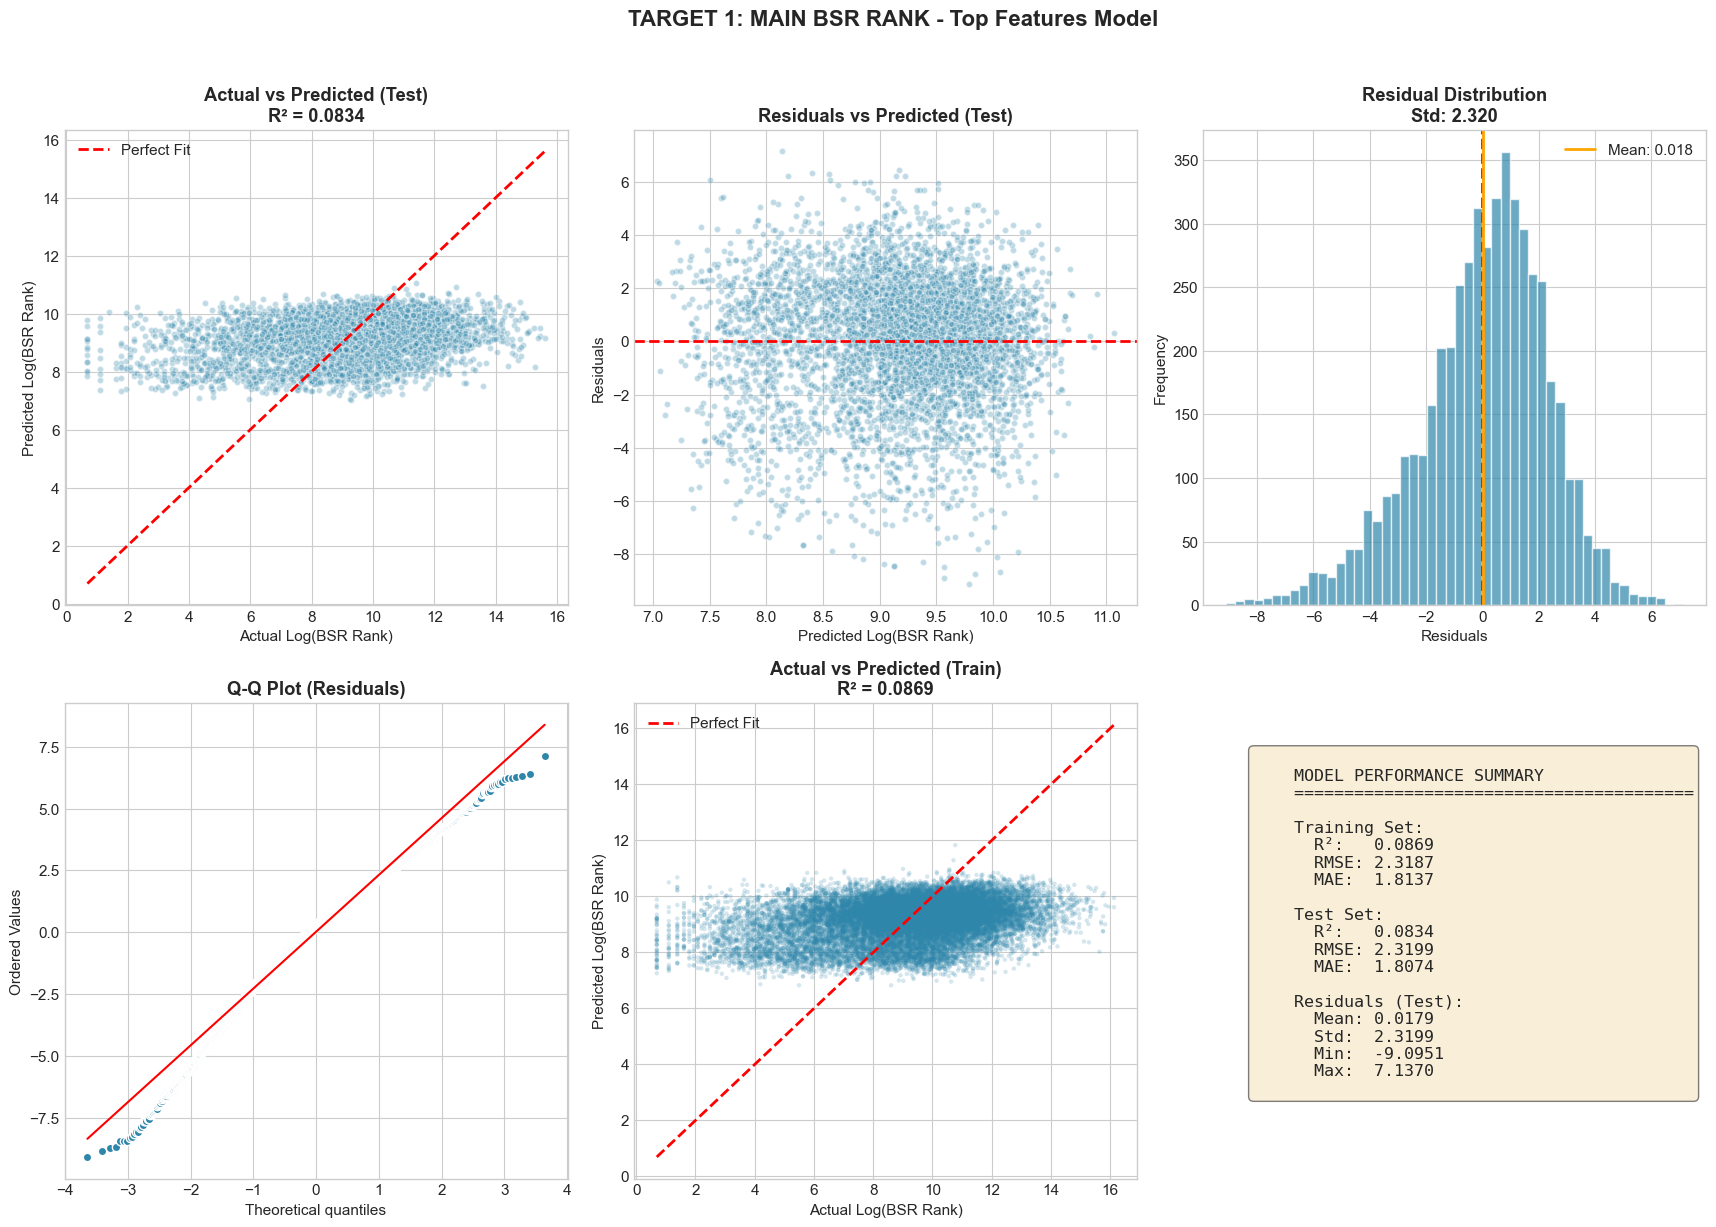

In [120]:
# Visualize results for Main BSR - Top Features
plot_regression_results(
    data_main_top['y_train'], data_main_top['y_test'],
    metrics_main_top['y_train_pred'], metrics_main_top['y_test_pred'],
    metrics_main_top,
    'TARGET 1: MAIN BSR RANK - Top Features Model',
    MAIN_BSR_COLOR
)

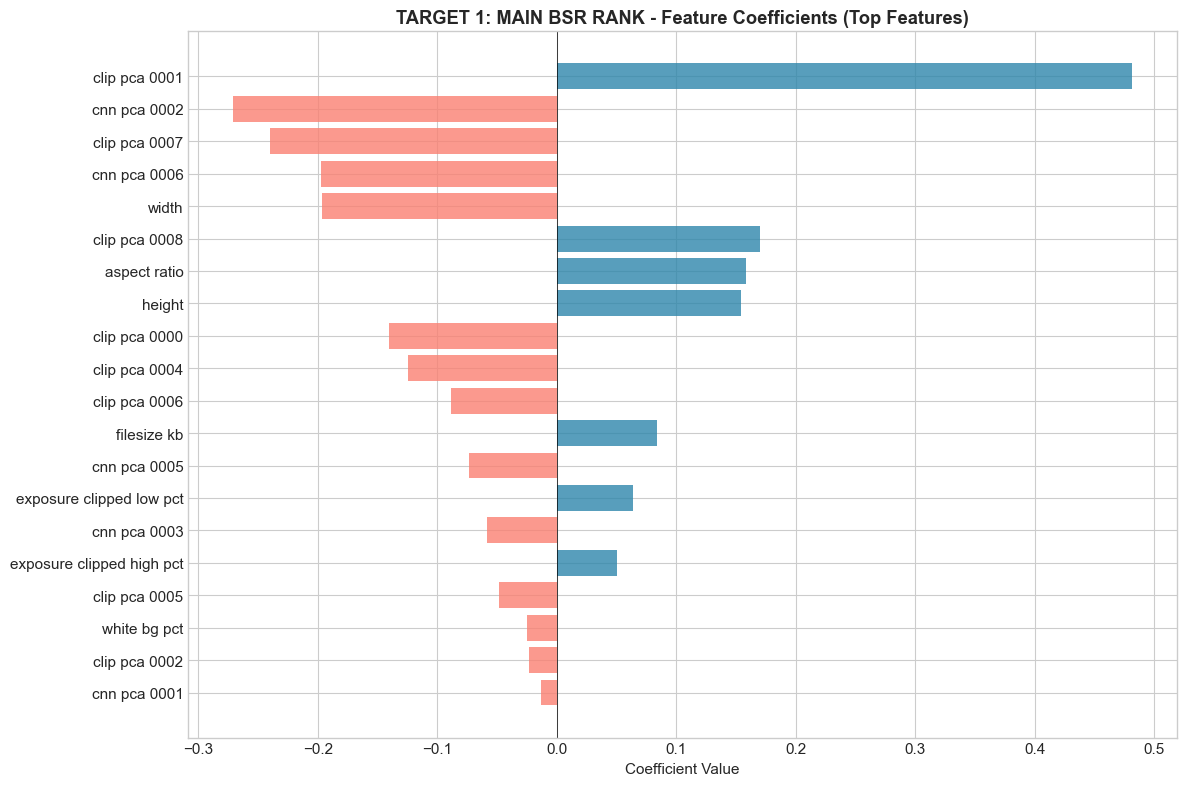

In [121]:
# Feature importance for Main BSR - Top Features
coef_main_top = plot_feature_importance(
    model_main_top, data_main_top['feature_names'],
    'TARGET 1: MAIN BSR RANK - Feature Coefficients (Top Features)',
    MAIN_BSR_COLOR
)

In [122]:
# =============================================================================
# 6. TARGET 1: MAIN BSR RANK - ALL FEATURES MODEL
# =============================================================================

print("="*70)
print("TARGET 1: MAIN BSR RANK - ALL FEATURES MODEL")
print("="*70)

# Prepare data with all features (excluding other target)
# Remove lowest_bsr columns from features
all_features_main = [f for f in all_feature_cols 
                     if 'lowest_bsr' not in f.lower()]

data_main_all = prepare_data(df, 'main_bsr_rank', all_features_main)

print(f"\nSamples: {data_main_all['n_samples']:,}")
print(f"Features: {len(data_main_all['feature_names'])}")
print(f"Train size: {len(data_main_all['y_train']):,}")
print(f"Test size: {len(data_main_all['y_test']):,}")

# Use Ridge regression for all features (regularization helps with many features)
model_main_all = Ridge(alpha=1.0)
model_main_all.fit(data_main_all['X_train'], data_main_all['y_train'])

# Evaluate
metrics_main_all = evaluate_model(
    model_main_all,
    data_main_all['X_train'], data_main_all['X_test'],
    data_main_all['y_train'], data_main_all['y_test']
)

print(f"\n*** Results ***")
print(f"Train R²: {metrics_main_all['train_r2']:.4f}")
print(f"Test R²:  {metrics_main_all['test_r2']:.4f}")
print(f"Test RMSE: {metrics_main_all['test_rmse']:.4f}")
print(f"Test MAE:  {metrics_main_all['test_mae']:.4f}")

TARGET 1: MAIN BSR RANK - ALL FEATURES MODEL
  Kept 7581 features after removing high-missing columns
  Final samples after cleaning: 25766

Samples: 25,766
Features: 7581
Train size: 20,612
Test size: 5,154

*** Results ***
Train R²: 0.3511
Test R²:  0.2228
Test RMSE: 2.1363
Test MAE:  1.6631


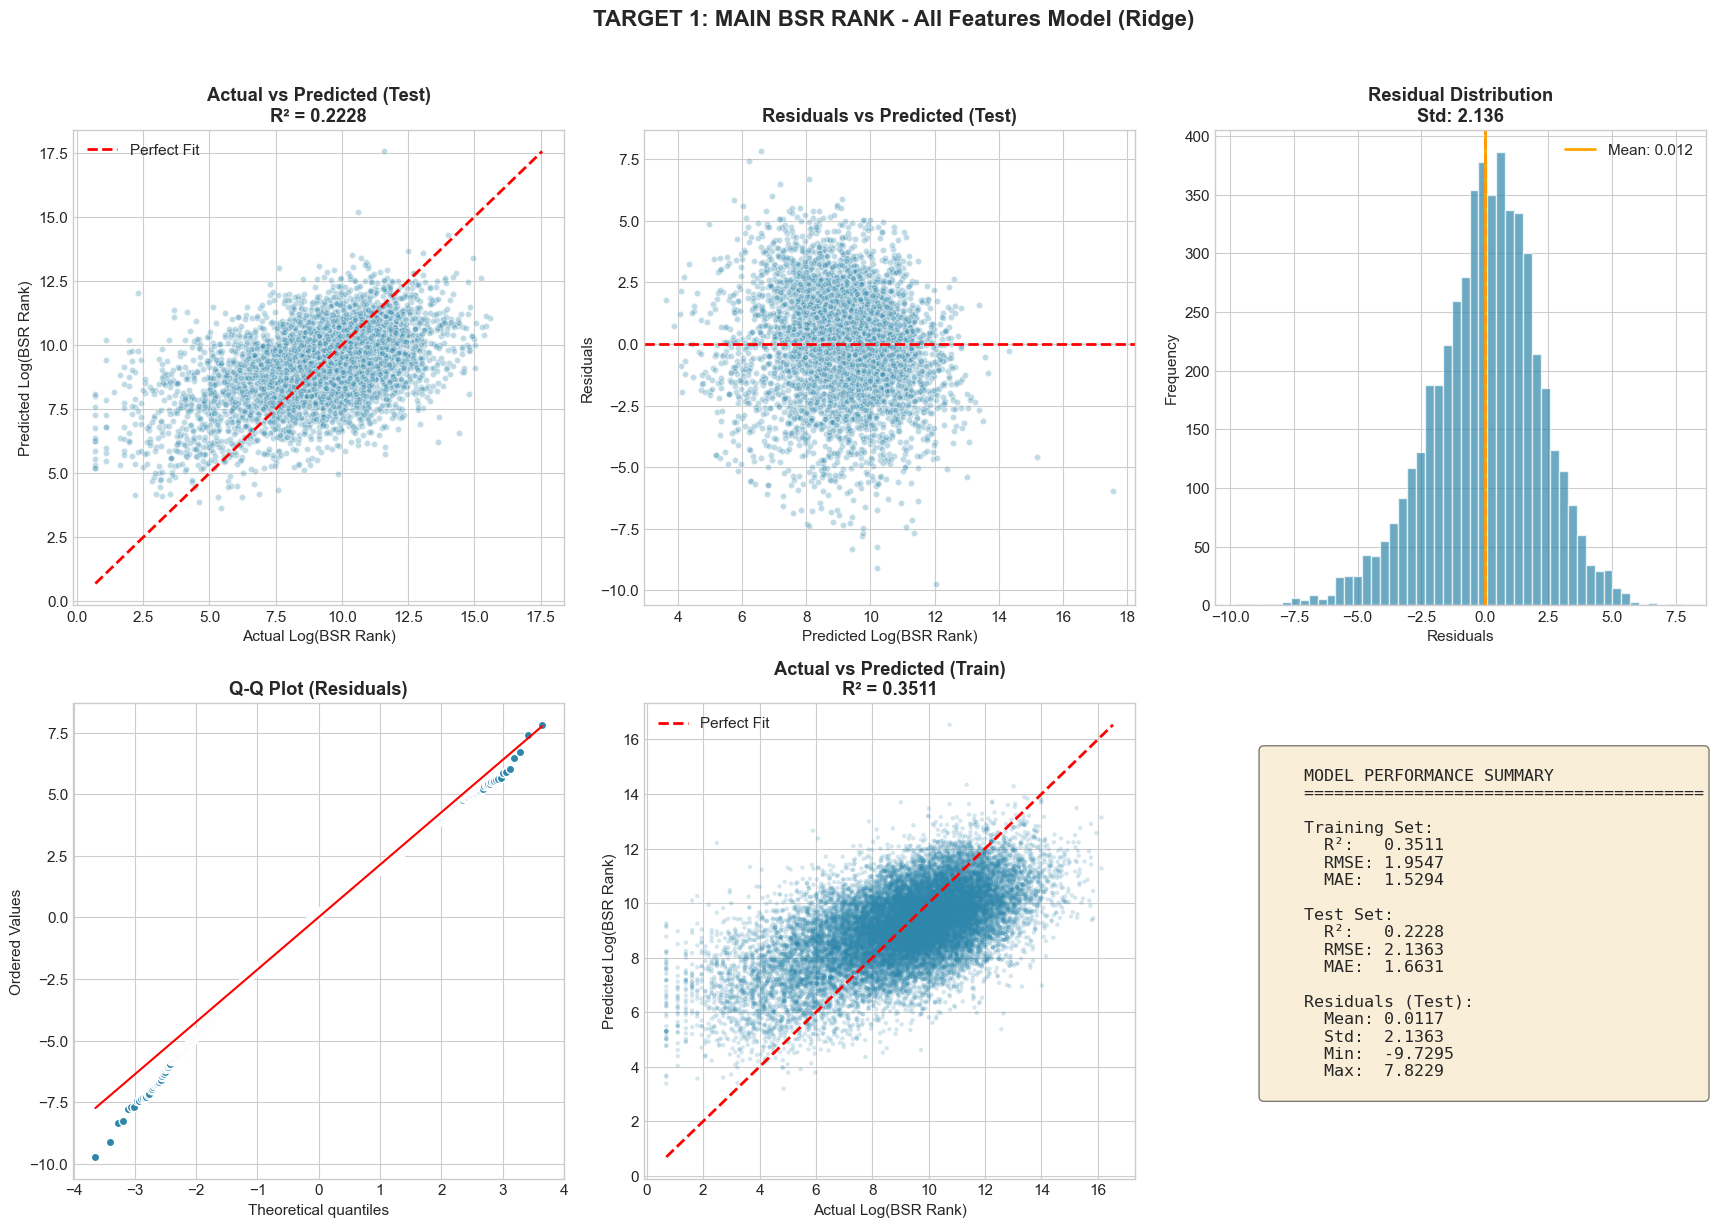

In [123]:
# Visualize results for Main BSR - All Features
plot_regression_results(
    data_main_all['y_train'], data_main_all['y_test'],
    metrics_main_all['y_train_pred'], metrics_main_all['y_test_pred'],
    metrics_main_all,
    'TARGET 1: MAIN BSR RANK - All Features Model (Ridge)',
    MAIN_BSR_COLOR
)

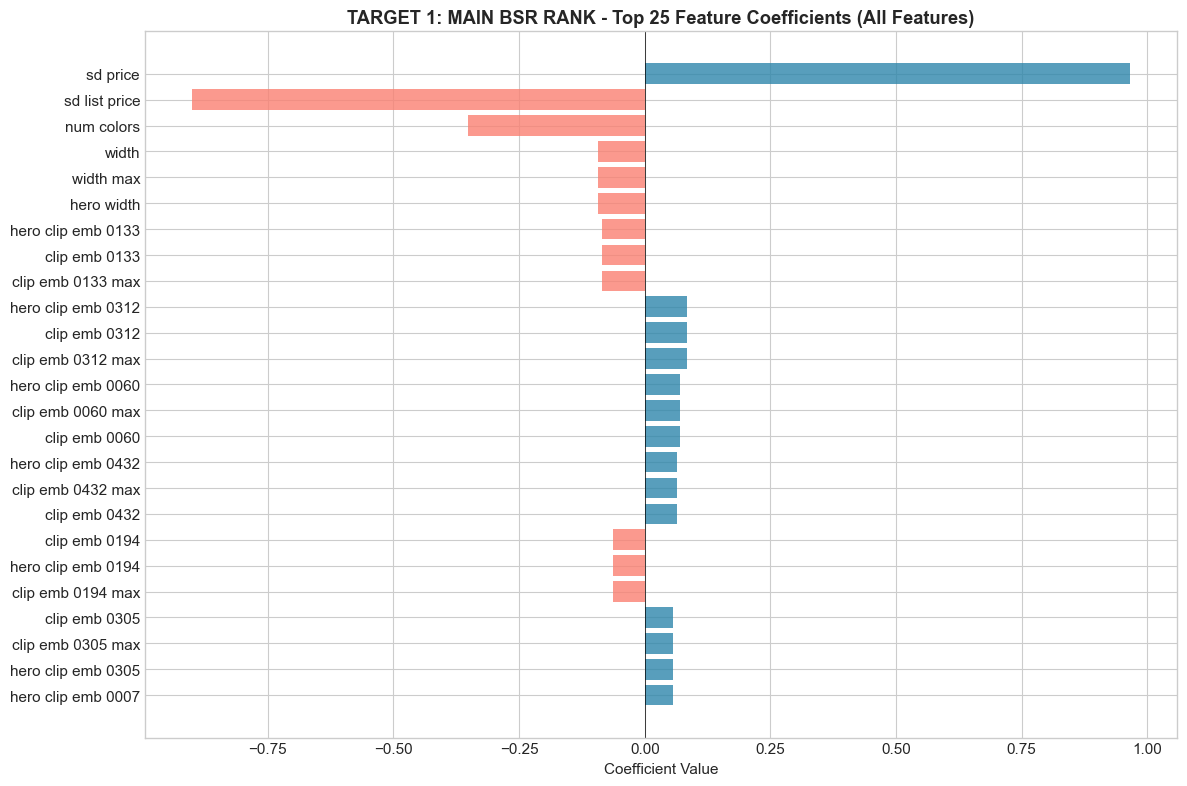

In [124]:
# Feature importance for Main BSR - All Features (top 25)
coef_main_all = plot_feature_importance(
    model_main_all, data_main_all['feature_names'],
    'TARGET 1: MAIN BSR RANK - Top 25 Feature Coefficients (All Features)',
    MAIN_BSR_COLOR,
    top_n=25
)

---
## TARGET 2: Lowest BSR Rank Prediction
Predicting the bestseller rank in the product's best subcategory (lowest rank).

**Color scheme: Magenta**

In [125]:
# =============================================================================
# 7. TARGET 2: LOWEST BSR RANK - TOP FEATURES MODEL
# =============================================================================

print("="*70)
print("TARGET 2: LOWEST BSR RANK - TOP FEATURES MODEL")
print("="*70)

# Prepare data with top features
data_lowest_top = prepare_data(df, 'lowest_bsr_rank', top_features)

print(f"\nSamples: {data_lowest_top['n_samples']:,}")
print(f"Features: {len(data_lowest_top['feature_names'])}")
print(f"Train size: {len(data_lowest_top['y_train']):,}")
print(f"Test size: {len(data_lowest_top['y_test']):,}")

# Train Linear Regression
model_lowest_top = LinearRegression()
model_lowest_top.fit(data_lowest_top['X_train'], data_lowest_top['y_train'])

# Evaluate
metrics_lowest_top = evaluate_model(
    model_lowest_top,
    data_lowest_top['X_train'], data_lowest_top['X_test'],
    data_lowest_top['y_train'], data_lowest_top['y_test']
)

print(f"\n*** Results ***")
print(f"Train R²: {metrics_lowest_top['train_r2']:.4f}")
print(f"Test R²:  {metrics_lowest_top['test_r2']:.4f}")
print(f"Test RMSE: {metrics_lowest_top['test_rmse']:.4f}")
print(f"Test MAE:  {metrics_lowest_top['test_mae']:.4f}")

TARGET 2: LOWEST BSR RANK - TOP FEATURES MODEL
  Kept 20 features after removing high-missing columns
  Final samples after cleaning: 25766

Samples: 25,766
Features: 20
Train size: 20,612
Test size: 5,154

*** Results ***
Train R²: 0.0254
Test R²:  0.0219
Test RMSE: 1.7888
Test MAE:  1.4118


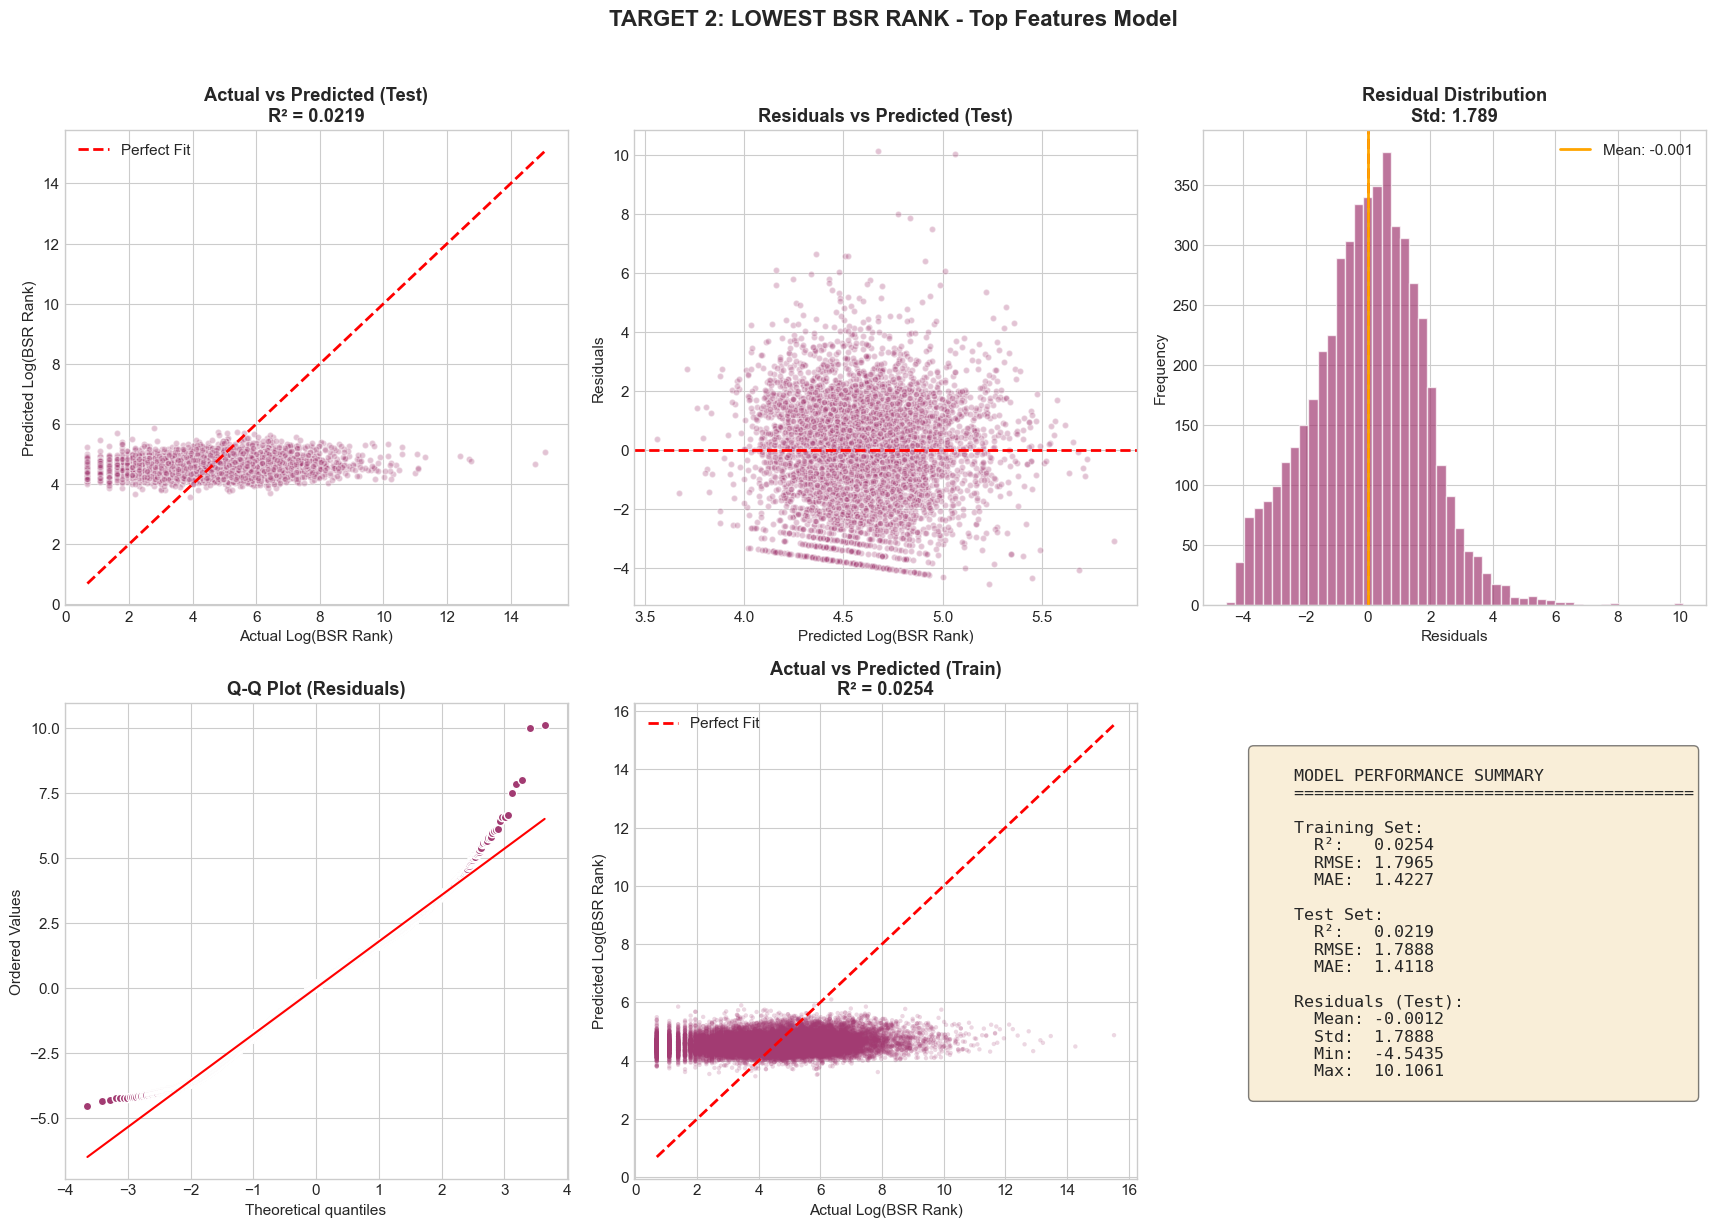

In [126]:
# Visualize results for Lowest BSR - Top Features
plot_regression_results(
    data_lowest_top['y_train'], data_lowest_top['y_test'],
    metrics_lowest_top['y_train_pred'], metrics_lowest_top['y_test_pred'],
    metrics_lowest_top,
    'TARGET 2: LOWEST BSR RANK - Top Features Model',
    LOWEST_BSR_COLOR
)

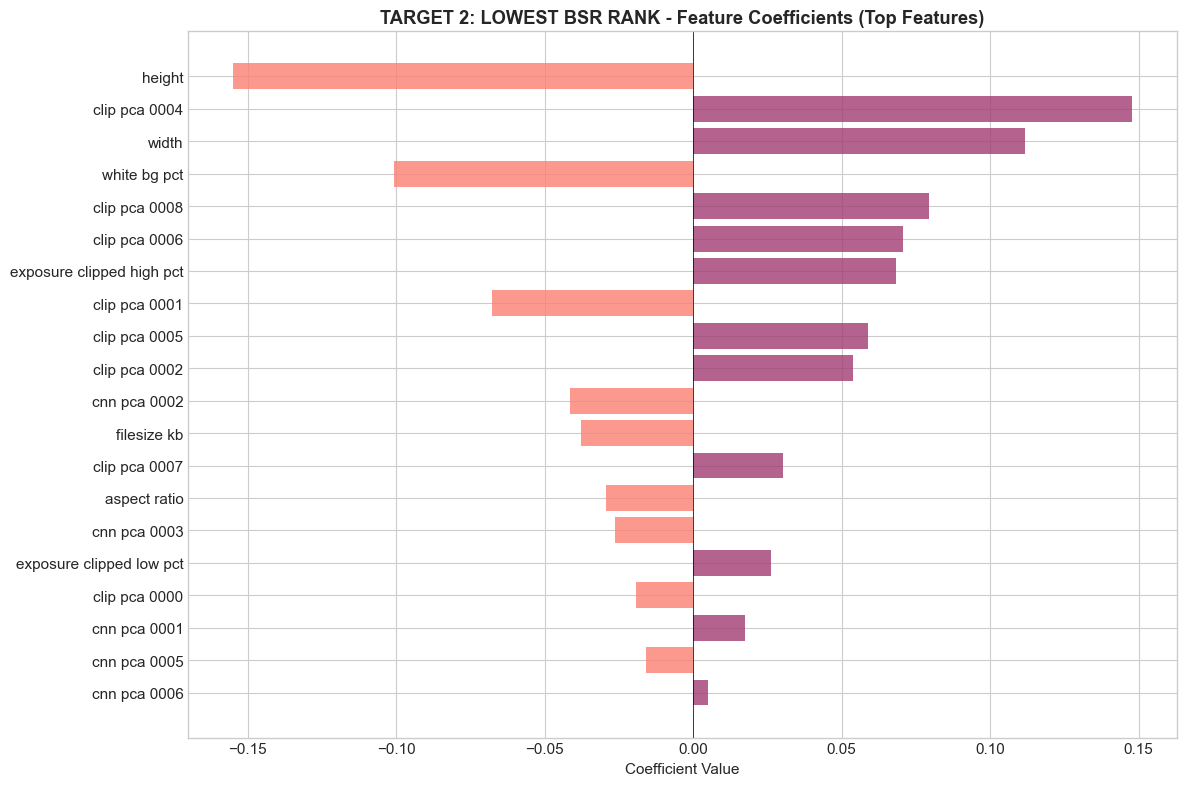

In [127]:
# Feature importance for Lowest BSR - Top Features
coef_lowest_top = plot_feature_importance(
    model_lowest_top, data_lowest_top['feature_names'],
    'TARGET 2: LOWEST BSR RANK - Feature Coefficients (Top Features)',
    LOWEST_BSR_COLOR
)

In [128]:
# =============================================================================
# 8. TARGET 2: LOWEST BSR RANK - ALL FEATURES MODEL
# =============================================================================

print("="*70)
print("TARGET 2: LOWEST BSR RANK - ALL FEATURES MODEL")
print("="*70)

# Prepare data with all features (excluding other target)
# Remove main_bsr columns from features
all_features_lowest = [f for f in all_feature_cols 
                       if 'main_bsr' not in f.lower()]

data_lowest_all = prepare_data(df, 'lowest_bsr_rank', all_features_lowest)

print(f"\nSamples: {data_lowest_all['n_samples']:,}")
print(f"Features: {len(data_lowest_all['feature_names'])}")
print(f"Train size: {len(data_lowest_all['y_train']):,}")
print(f"Test size: {len(data_lowest_all['y_test']):,}")

# Use Ridge regression for all features
model_lowest_all = Ridge(alpha=1.0)
model_lowest_all.fit(data_lowest_all['X_train'], data_lowest_all['y_train'])

# Evaluate
metrics_lowest_all = evaluate_model(
    model_lowest_all,
    data_lowest_all['X_train'], data_lowest_all['X_test'],
    data_lowest_all['y_train'], data_lowest_all['y_test']
)

print(f"\n*** Results ***")
print(f"Train R²: {metrics_lowest_all['train_r2']:.4f}")
print(f"Test R²:  {metrics_lowest_all['test_r2']:.4f}")
print(f"Test RMSE: {metrics_lowest_all['test_rmse']:.4f}")
print(f"Test MAE:  {metrics_lowest_all['test_mae']:.4f}")

TARGET 2: LOWEST BSR RANK - ALL FEATURES MODEL
  Kept 7581 features after removing high-missing columns
  Final samples after cleaning: 25766

Samples: 25,766
Features: 7581
Train size: 20,612
Test size: 5,154

*** Results ***
Train R²: 0.2389
Test R²:  0.0636
Test RMSE: 1.7502
Test MAE:  1.3799


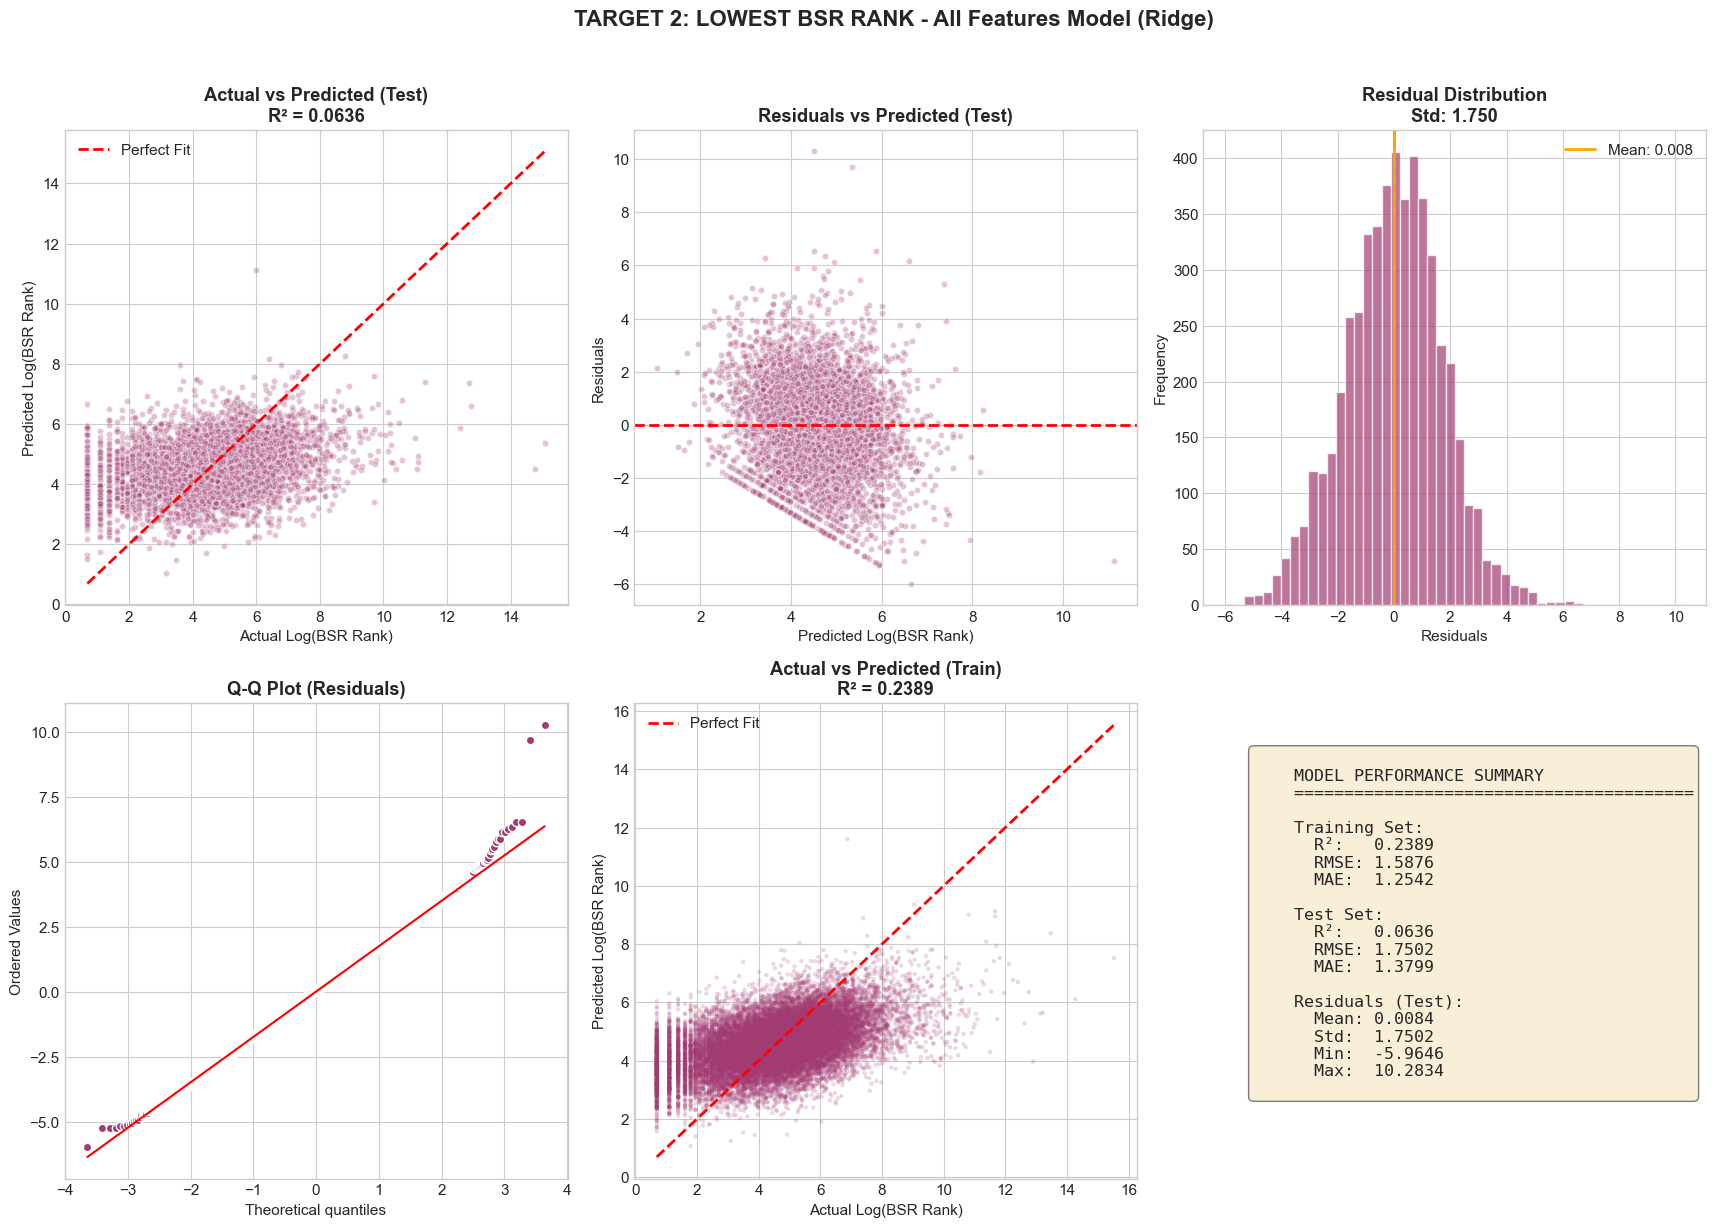

In [129]:
# Visualize results for Lowest BSR - All Features
plot_regression_results(
    data_lowest_all['y_train'], data_lowest_all['y_test'],
    metrics_lowest_all['y_train_pred'], metrics_lowest_all['y_test_pred'],
    metrics_lowest_all,
    'TARGET 2: LOWEST BSR RANK - All Features Model (Ridge)',
    LOWEST_BSR_COLOR
)

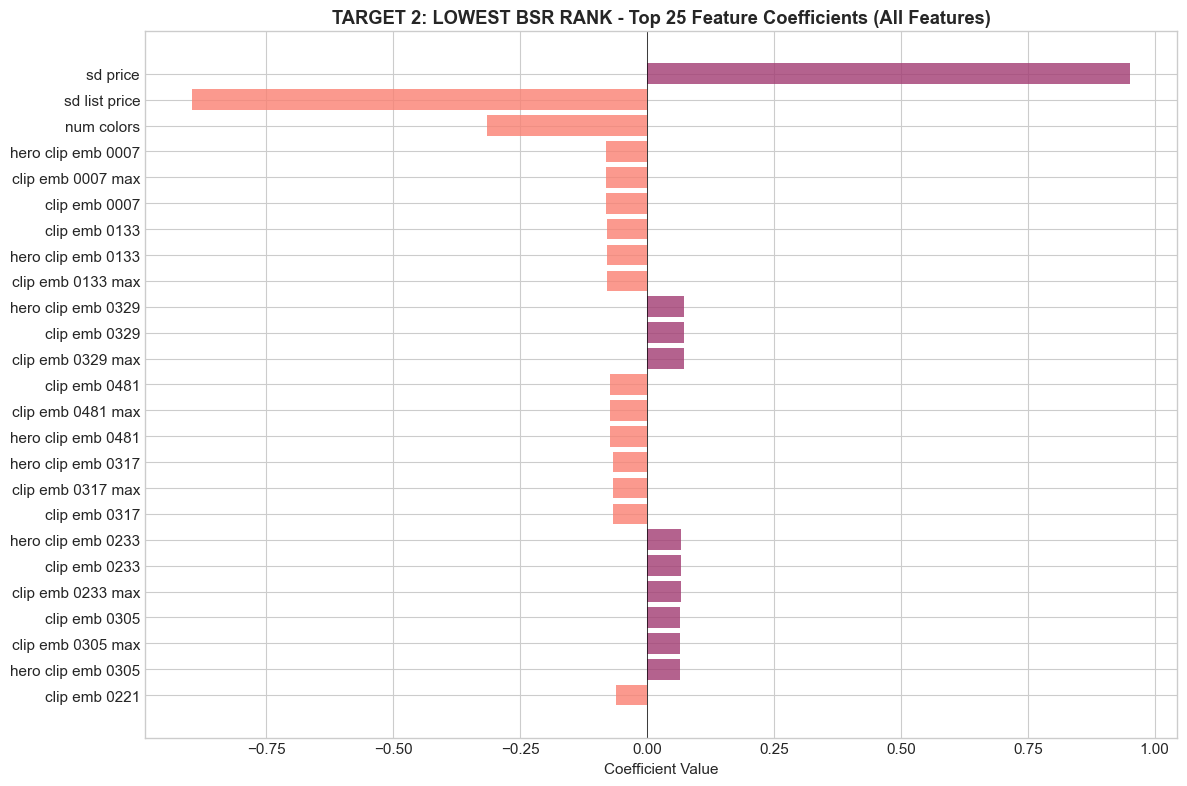

In [130]:
# Feature importance for Lowest BSR - All Features (top 25)
coef_lowest_all = plot_feature_importance(
    model_lowest_all, data_lowest_all['feature_names'],
    'TARGET 2: LOWEST BSR RANK - Top 25 Feature Coefficients (All Features)',
    LOWEST_BSR_COLOR,
    top_n=25
)

---
## Model Comparison Summary

In [131]:
# =============================================================================
# 9. MODEL COMPARISON SUMMARY
# =============================================================================

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': [
        'Main BSR - Top Features',
        'Main BSR - All Features (Ridge)',
        'Lowest BSR - Top Features',
        'Lowest BSR - All Features (Ridge)'
    ],
    'Target': ['Main BSR', 'Main BSR', 'Lowest BSR', 'Lowest BSR'],
    'N_Features': [
        len(data_main_top['feature_names']),
        len(data_main_all['feature_names']),
        len(data_lowest_top['feature_names']),
        len(data_lowest_all['feature_names'])
    ],
    'Train_R2': [
        metrics_main_top['train_r2'],
        metrics_main_all['train_r2'],
        metrics_lowest_top['train_r2'],
        metrics_lowest_all['train_r2']
    ],
    'Test_R2': [
        metrics_main_top['test_r2'],
        metrics_main_all['test_r2'],
        metrics_lowest_top['test_r2'],
        metrics_lowest_all['test_r2']
    ],
    'Test_RMSE': [
        metrics_main_top['test_rmse'],
        metrics_main_all['test_rmse'],
        metrics_lowest_top['test_rmse'],
        metrics_lowest_all['test_rmse']
    ],
    'Test_MAE': [
        metrics_main_top['test_mae'],
        metrics_main_all['test_mae'],
        metrics_lowest_top['test_mae'],
        metrics_lowest_all['test_mae']
    ]
})

print("="*90)
print("MODEL COMPARISON SUMMARY")
print("="*90)
print()
print(comparison.to_string(index=False))

MODEL COMPARISON SUMMARY

                            Model     Target  N_Features  Train_R2  Test_R2  Test_RMSE  Test_MAE
          Main BSR - Top Features   Main BSR          20  0.086850 0.083443   2.319944  1.807414
  Main BSR - All Features (Ridge)   Main BSR        7581  0.351070 0.222800   2.136310  1.663062
        Lowest BSR - Top Features Lowest BSR          20  0.025369 0.021876   1.788771  1.411802
Lowest BSR - All Features (Ridge) Lowest BSR        7581  0.238891 0.063614   1.750191  1.379904


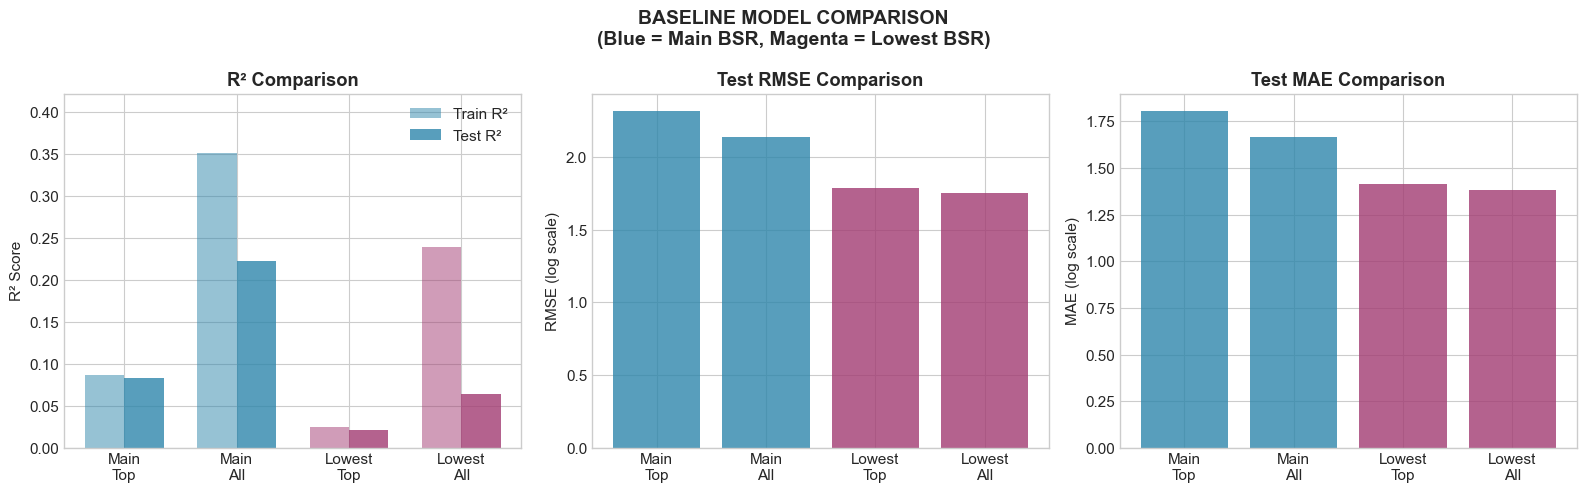

In [132]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² comparison
ax1 = axes[0]
x = np.arange(4)
width = 0.35
bars1 = ax1.bar(x - width/2, comparison['Train_R2'], width, label='Train R²', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison['Test_R2'], width, label='Test R²', alpha=0.8)
# Color by target
colors = [MAIN_BSR_COLOR, MAIN_BSR_COLOR, LOWEST_BSR_COLOR, LOWEST_BSR_COLOR]
for bar, color in zip(bars1, colors):
    bar.set_facecolor(color)
    bar.set_alpha(0.5)
for bar, color in zip(bars2, colors):
    bar.set_facecolor(color)
ax1.set_ylabel('R² Score')
ax1.set_title('R² Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Main\nTop', 'Main\nAll', 'Lowest\nTop', 'Lowest\nAll'])
ax1.legend()
ax1.set_ylim(0, max(comparison['Train_R2'].max(), comparison['Test_R2'].max()) * 1.2)

# RMSE comparison
ax2 = axes[1]
bars = ax2.bar(x, comparison['Test_RMSE'], color=colors, alpha=0.8)
ax2.set_ylabel('RMSE (log scale)')
ax2.set_title('Test RMSE Comparison', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Main\nTop', 'Main\nAll', 'Lowest\nTop', 'Lowest\nAll'])

# MAE comparison
ax3 = axes[2]
bars = ax3.bar(x, comparison['Test_MAE'], color=colors, alpha=0.8)
ax3.set_ylabel('MAE (log scale)')
ax3.set_title('Test MAE Comparison', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Main\nTop', 'Main\nAll', 'Lowest\nTop', 'Lowest\nAll'])

plt.suptitle('BASELINE MODEL COMPARISON\n(Blue = Main BSR, Magenta = Lowest BSR)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

5-FOLD CROSS-VALIDATION RESULTS

Model                    Mean R²     Std R²
--------------------------------------------------
Main BSR - Top           0.0847      0.0121
Main BSR - All           0.1949      0.0278
Lowest BSR - Top         0.0229      0.0057
Lowest BSR - All         0.0494      0.0139


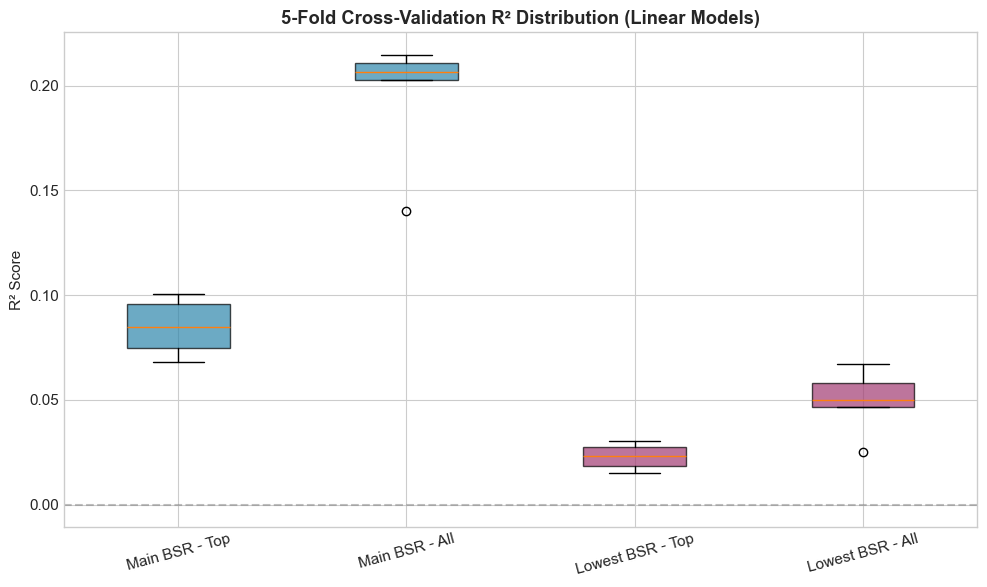

In [133]:
# =============================================================================
# 10. CROSS-VALIDATION ANALYSIS
# =============================================================================

from sklearn.model_selection import cross_val_score

print("="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)

# Cross-validation for each model
cv_results = {}

# Main BSR - Top Features
cv_main_top = cross_val_score(
    LinearRegression(), 
    data_main_top['X_train'], 
    data_main_top['y_train'], 
    cv=5, scoring='r2'
)
cv_results['Main BSR - Top'] = cv_main_top

# Main BSR - All Features
cv_main_all = cross_val_score(
    Ridge(alpha=1.0), 
    data_main_all['X_train'], 
    data_main_all['y_train'], 
    cv=5, scoring='r2'
)
cv_results['Main BSR - All'] = cv_main_all

# Lowest BSR - Top Features
cv_lowest_top = cross_val_score(
    LinearRegression(), 
    data_lowest_top['X_train'], 
    data_lowest_top['y_train'], 
    cv=5, scoring='r2'
)
cv_results['Lowest BSR - Top'] = cv_lowest_top

# Lowest BSR - All Features
cv_lowest_all = cross_val_score(
    Ridge(alpha=1.0), 
    data_lowest_all['X_train'], 
    data_lowest_all['y_train'], 
    cv=5, scoring='r2'
)
cv_results['Lowest BSR - All'] = cv_lowest_all

# Print results
print("\nModel                    Mean R²     Std R²")
print("-" * 50)
for name, scores in cv_results.items():
    print(f"{name:24} {scores.mean():.4f}      {scores.std():.4f}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(cv_results))
colors = [MAIN_BSR_COLOR, MAIN_BSR_COLOR, LOWEST_BSR_COLOR, LOWEST_BSR_COLOR]

bp = ax.boxplot([cv_results[k] for k in cv_results.keys()], 
                positions=positions, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(list(cv_results.keys()), rotation=15)
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² Distribution (Linear Models)', fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## PART 2: Non-Linear Baseline Models
Training ensemble tree-based models: Random Forest, XGBoost, and LightGBM.

Using default hyperparameters for baseline comparison.

In [134]:
# =============================================================================
# 11. NON-LINEAR MODELS - IMPORTS AND SETUP
# =============================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from tqdm.auto import tqdm
import time

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost loaded successfully")
except ImportError:
    HAS_XGB = False
    print("XGBoost not available")

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("LightGBM loaded successfully")
except ImportError:
    HAS_LGB = False
    print("LightGBM not available")

# Cross-validation setup
CV_FOLDS = 5
CV_FOLDS_FAST = 3  # Fewer folds for high-dimensional data
kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
kfold_fast = KFold(n_splits=CV_FOLDS_FAST, shuffle=True, random_state=42)

print(f"\nUsing {CV_FOLDS}-fold cross-validation for model evaluation")

XGBoost loaded successfully
LightGBM not available

Using 5-fold cross-validation for model evaluation


In [135]:
# =============================================================================
# 12. DEFINE NON-LINEAR MODELS (Default Hyperparameters)
# =============================================================================

def get_nonlinear_models(fast_mode=False):
    """
    Return dictionary of non-linear models.
    fast_mode=True: Faster settings for high-dimensional data (All Features)
    fast_mode=False: Standard settings for low-dimensional data (Top Features)
    """
    if fast_mode:
        # Faster settings for 7000+ features
        n_est = 50
        rf_max_depth = 15
        rf_max_features = 'sqrt'  # Only consider sqrt(n_features) at each split
    else:
        # Standard settings for ~20 features
        n_est = 100
        rf_max_depth = None
        rf_max_features = 'sqrt'
    
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=n_est,
            max_depth=rf_max_depth,
            max_features=rf_max_features,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        )
    }
    
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBRegressor(
            n_estimators=n_est,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.3 if fast_mode else 0.8,  # Sample fewer features per tree
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )
    
    if HAS_LGB:
        models['LightGBM'] = lgb.LGBMRegressor(
            n_estimators=n_est,
            max_depth=15 if fast_mode else -1,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.3 if fast_mode else 0.8,
            n_jobs=-1,
            random_state=42,
            verbose=-1
        )
    
    return models

print("Non-linear models defined:")
for name in get_nonlinear_models().keys():
    print(f"  - {name}")

Non-linear models defined:
  - Random Forest
  - XGBoost


In [136]:
# =============================================================================
# 13. TRAIN NON-LINEAR MODELS - MAIN BSR (TOP FEATURES)
# =============================================================================

print("="*80)
print("TARGET 1: MAIN BSR RANK - NON-LINEAR MODELS (TOP FEATURES)")
print("="*80)

nonlinear_results_main_top = {}
models_dict = get_nonlinear_models(fast_mode=False)  # Standard mode for top features

for name, model in tqdm(models_dict.items(), desc='Training models'):
    start_time = time.time()
    
    # Cross-validation
    cv_scores = cross_val_score(model, data_main_top['X_train'], data_main_top['y_train'], 
                                cv=kfold, scoring='r2')
    
    # Fit on full training set
    model.fit(data_main_top['X_train'], data_main_top['y_train'])
    
    # Evaluate
    y_train_pred = model.predict(data_main_top['X_train'])
    y_test_pred = model.predict(data_main_top['X_test'])
    
    train_r2 = r2_score(data_main_top['y_train'], y_train_pred)
    test_r2 = r2_score(data_main_top['y_test'], y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(data_main_top['y_test'], y_test_pred))
    test_mae = mean_absolute_error(data_main_top['y_test'], y_test_pred)
    elapsed = time.time() - start_time
    
    nonlinear_results_main_top[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'model': model,
        'time': elapsed
    }
    
    print(f"  {name}: CV R²={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Test R²={test_r2:.4f}, RMSE={test_rmse:.4f} [{elapsed:.1f}s]")

TARGET 1: MAIN BSR RANK - NON-LINEAR MODELS (TOP FEATURES)


Training models:  50%|█████     | 1/2 [00:08<00:08,  8.29s/it]

  Random Forest: CV R²=0.2631(+/-0.0087), Test R²=0.2845, RMSE=2.0498 [8.3s]


Training models: 100%|██████████| 2/2 [00:09<00:00,  4.81s/it]

  XGBoost: CV R²=0.2202(+/-0.0079), Test R²=0.2405, RMSE=2.1118 [1.3s]


In [137]:
# =============================================================================
# 14. TRAIN NON-LINEAR MODELS - MAIN BSR (ALL FEATURES)
# =============================================================================
# Using fast_mode=True and 3-fold CV for speed with 7000+ features

print("="*80)
print("TARGET 1: MAIN BSR RANK - NON-LINEAR MODELS (ALL FEATURES)")
print(f"Using fast_mode with {CV_FOLDS_FAST}-fold CV for speed")
print("="*80)

nonlinear_results_main_all = {}
models_dict = get_nonlinear_models(fast_mode=True)  # Fast mode for all features

for name, model in tqdm(models_dict.items(), desc='Training models (ALL features)'):
    start_time = time.time()
    
    # Cross-validation (fewer folds for speed)
    cv_scores = cross_val_score(model, data_main_all['X_train'], data_main_all['y_train'], 
                                cv=kfold_fast, scoring='r2')
    
    # Fit on full training set
    model.fit(data_main_all['X_train'], data_main_all['y_train'])
    
    # Evaluate
    y_train_pred = model.predict(data_main_all['X_train'])
    y_test_pred = model.predict(data_main_all['X_test'])
    
    train_r2 = r2_score(data_main_all['y_train'], y_train_pred)
    test_r2 = r2_score(data_main_all['y_test'], y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(data_main_all['y_test'], y_test_pred))
    test_mae = mean_absolute_error(data_main_all['y_test'], y_test_pred)
    elapsed = time.time() - start_time
    
    nonlinear_results_main_all[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'model': model,
        'time': elapsed
    }
    
    print(f"  {name}: CV R²={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Test R²={test_r2:.4f}, RMSE={test_rmse:.4f} [{elapsed:.1f}s]")

TARGET 1: MAIN BSR RANK - NON-LINEAR MODELS (ALL FEATURES)
Using fast_mode with 3-fold CV for speed


Training models (ALL features):  50%|█████     | 1/2 [00:38<00:38, 38.83s/it]

  Random Forest: CV R²=0.2110(+/-0.0042), Test R²=0.2425, RMSE=2.1091 [38.8s]


Training models (ALL features): 100%|██████████| 2/2 [02:04<00:00, 62.29s/it]

  XGBoost: CV R²=0.2837(+/-0.0048), Test R²=0.3115, RMSE=2.0107 [85.7s]


In [138]:
# =============================================================================
# 15. TRAIN NON-LINEAR MODELS - LOWEST BSR (TOP FEATURES)
# =============================================================================

print("="*80)
print("TARGET 2: LOWEST BSR RANK - NON-LINEAR MODELS (TOP FEATURES)")
print("="*80)

nonlinear_results_lowest_top = {}
models_dict = get_nonlinear_models(fast_mode=False)  # Standard mode for top features

for name, model in tqdm(models_dict.items(), desc='Training models'):
    start_time = time.time()
    
    # Cross-validation
    cv_scores = cross_val_score(model, data_lowest_top['X_train'], data_lowest_top['y_train'], 
                                cv=kfold, scoring='r2')
    
    # Fit on full training set
    model.fit(data_lowest_top['X_train'], data_lowest_top['y_train'])
    
    # Evaluate
    y_train_pred = model.predict(data_lowest_top['X_train'])
    y_test_pred = model.predict(data_lowest_top['X_test'])
    
    train_r2 = r2_score(data_lowest_top['y_train'], y_train_pred)
    test_r2 = r2_score(data_lowest_top['y_test'], y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(data_lowest_top['y_test'], y_test_pred))
    test_mae = mean_absolute_error(data_lowest_top['y_test'], y_test_pred)
    elapsed = time.time() - start_time
    
    nonlinear_results_lowest_top[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'model': model,
        'time': elapsed
    }
    
    print(f"  {name}: CV R²={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Test R²={test_r2:.4f}, RMSE={test_rmse:.4f} [{elapsed:.1f}s]")

TARGET 2: LOWEST BSR RANK - NON-LINEAR MODELS (TOP FEATURES)


Training models:  50%|█████     | 1/2 [00:07<00:07,  7.86s/it]

  Random Forest: CV R²=0.1155(+/-0.0043), Test R²=0.1361, RMSE=1.6810 [7.9s]


Training models: 100%|██████████| 2/2 [00:08<00:00,  4.49s/it]

  XGBoost: CV R²=0.0719(+/-0.0082), Test R²=0.0926, RMSE=1.7229 [1.1s]


In [139]:
# =============================================================================
# 16. TRAIN NON-LINEAR MODELS - LOWEST BSR (ALL FEATURES)
# =============================================================================
# Using fast_mode=True and 3-fold CV for speed with 7000+ features

print("="*80)
print("TARGET 2: LOWEST BSR RANK - NON-LINEAR MODELS (ALL FEATURES)")
print(f"Using fast_mode with {CV_FOLDS_FAST}-fold CV for speed")
print("="*80)

nonlinear_results_lowest_all = {}
models_dict = get_nonlinear_models(fast_mode=True)  # Fast mode for all features

for name, model in tqdm(models_dict.items(), desc='Training models (ALL features)'):
    start_time = time.time()
    
    # Cross-validation (fewer folds for speed)
    cv_scores = cross_val_score(model, data_lowest_all['X_train'], data_lowest_all['y_train'], 
                                cv=kfold_fast, scoring='r2')
    
    # Fit on full training set
    model.fit(data_lowest_all['X_train'], data_lowest_all['y_train'])
    
    # Evaluate
    y_train_pred = model.predict(data_lowest_all['X_train'])
    y_test_pred = model.predict(data_lowest_all['X_test'])
    
    train_r2 = r2_score(data_lowest_all['y_train'], y_train_pred)
    test_r2 = r2_score(data_lowest_all['y_test'], y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(data_lowest_all['y_test'], y_test_pred))
    test_mae = mean_absolute_error(data_lowest_all['y_test'], y_test_pred)
    elapsed = time.time() - start_time
    
    nonlinear_results_lowest_all[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'model': model,
        'time': elapsed
    }
    
    print(f"  {name}: CV R²={cv_scores.mean():.4f}(+/-{cv_scores.std():.4f}), Test R²={test_r2:.4f}, RMSE={test_rmse:.4f} [{elapsed:.1f}s]")

TARGET 2: LOWEST BSR RANK - NON-LINEAR MODELS (ALL FEATURES)
Using fast_mode with 3-fold CV for speed


Training models (ALL features):  50%|█████     | 1/2 [00:33<00:33, 33.89s/it]

  Random Forest: CV R²=0.0857(+/-0.0006), Test R²=0.1035, RMSE=1.7125 [33.9s]


Training models (ALL features): 100%|██████████| 2/2 [01:56<00:00, 58.44s/it]

  XGBoost: CV R²=0.1216(+/-0.0068), Test R²=0.1399, RMSE=1.6773 [83.0s]


In [140]:
# =============================================================================
# 17. NON-LINEAR MODELS COMPARISON
# =============================================================================

print("="*90)
print("NON-LINEAR MODELS COMPARISON")
print("="*90)

# Build comparison dataframe
nonlinear_comparison_rows = []

# Main BSR - Top Features
for name, results in nonlinear_results_main_top.items():
    nonlinear_comparison_rows.append({
        'Model': f'{name} (Top)',
        'Target': 'Main BSR',
        'N_Features': len(data_main_top['feature_names']),
        'CV_R2_Mean': results['cv_mean'],
        'CV_R2_Std': results['cv_std'],
        'Train_R2': results['train_r2'],
        'Test_R2': results['test_r2'],
        'Test_RMSE': results['test_rmse'],
        'Test_MAE': results['test_mae']
    })

# Main BSR - All Features
for name, results in nonlinear_results_main_all.items():
    nonlinear_comparison_rows.append({
        'Model': f'{name} (All)',
        'Target': 'Main BSR',
        'N_Features': len(data_main_all['feature_names']),
        'CV_R2_Mean': results['cv_mean'],
        'CV_R2_Std': results['cv_std'],
        'Train_R2': results['train_r2'],
        'Test_R2': results['test_r2'],
        'Test_RMSE': results['test_rmse'],
        'Test_MAE': results['test_mae']
    })

# Lowest BSR - Top Features
for name, results in nonlinear_results_lowest_top.items():
    nonlinear_comparison_rows.append({
        'Model': f'{name} (Top)',
        'Target': 'Lowest BSR',
        'N_Features': len(data_lowest_top['feature_names']),
        'CV_R2_Mean': results['cv_mean'],
        'CV_R2_Std': results['cv_std'],
        'Train_R2': results['train_r2'],
        'Test_R2': results['test_r2'],
        'Test_RMSE': results['test_rmse'],
        'Test_MAE': results['test_mae']
    })

# Lowest BSR - All Features
for name, results in nonlinear_results_lowest_all.items():
    nonlinear_comparison_rows.append({
        'Model': f'{name} (All)',
        'Target': 'Lowest BSR',
        'N_Features': len(data_lowest_all['feature_names']),
        'CV_R2_Mean': results['cv_mean'],
        'CV_R2_Std': results['cv_std'],
        'Train_R2': results['train_r2'],
        'Test_R2': results['test_r2'],
        'Test_RMSE': results['test_rmse'],
        'Test_MAE': results['test_mae']
    })

nonlinear_comparison = pd.DataFrame(nonlinear_comparison_rows)
print("\n" + nonlinear_comparison.to_string(index=False))

NON-LINEAR MODELS COMPARISON

              Model     Target  N_Features  CV_R2_Mean  CV_R2_Std  Train_R2  Test_R2  Test_RMSE  Test_MAE
Random Forest (Top)   Main BSR          20    0.263100   0.008678  0.821137 0.284457   2.049820  1.580032
      XGBoost (Top)   Main BSR          20    0.220189   0.007908  0.436468 0.240539   2.111789  1.634494
Random Forest (All)   Main BSR        7581    0.210952   0.004231  0.713738 0.242451   2.109129  1.636118
      XGBoost (All)   Main BSR        7581    0.283730   0.004834  0.536373 0.311506   2.010703  1.554781
Random Forest (Top) Lowest BSR          20    0.115541   0.004256  0.785923 0.136141   1.681045  1.310322
      XGBoost (Top) Lowest BSR          20    0.071866   0.008232  0.310474 0.092587   1.722901  1.355043
Random Forest (All) Lowest BSR        7581    0.085737   0.000585  0.578448 0.103515   1.712495  1.342365
      XGBoost (All) Lowest BSR        7581    0.121563   0.006786  0.402557 0.139941   1.677343  1.319988


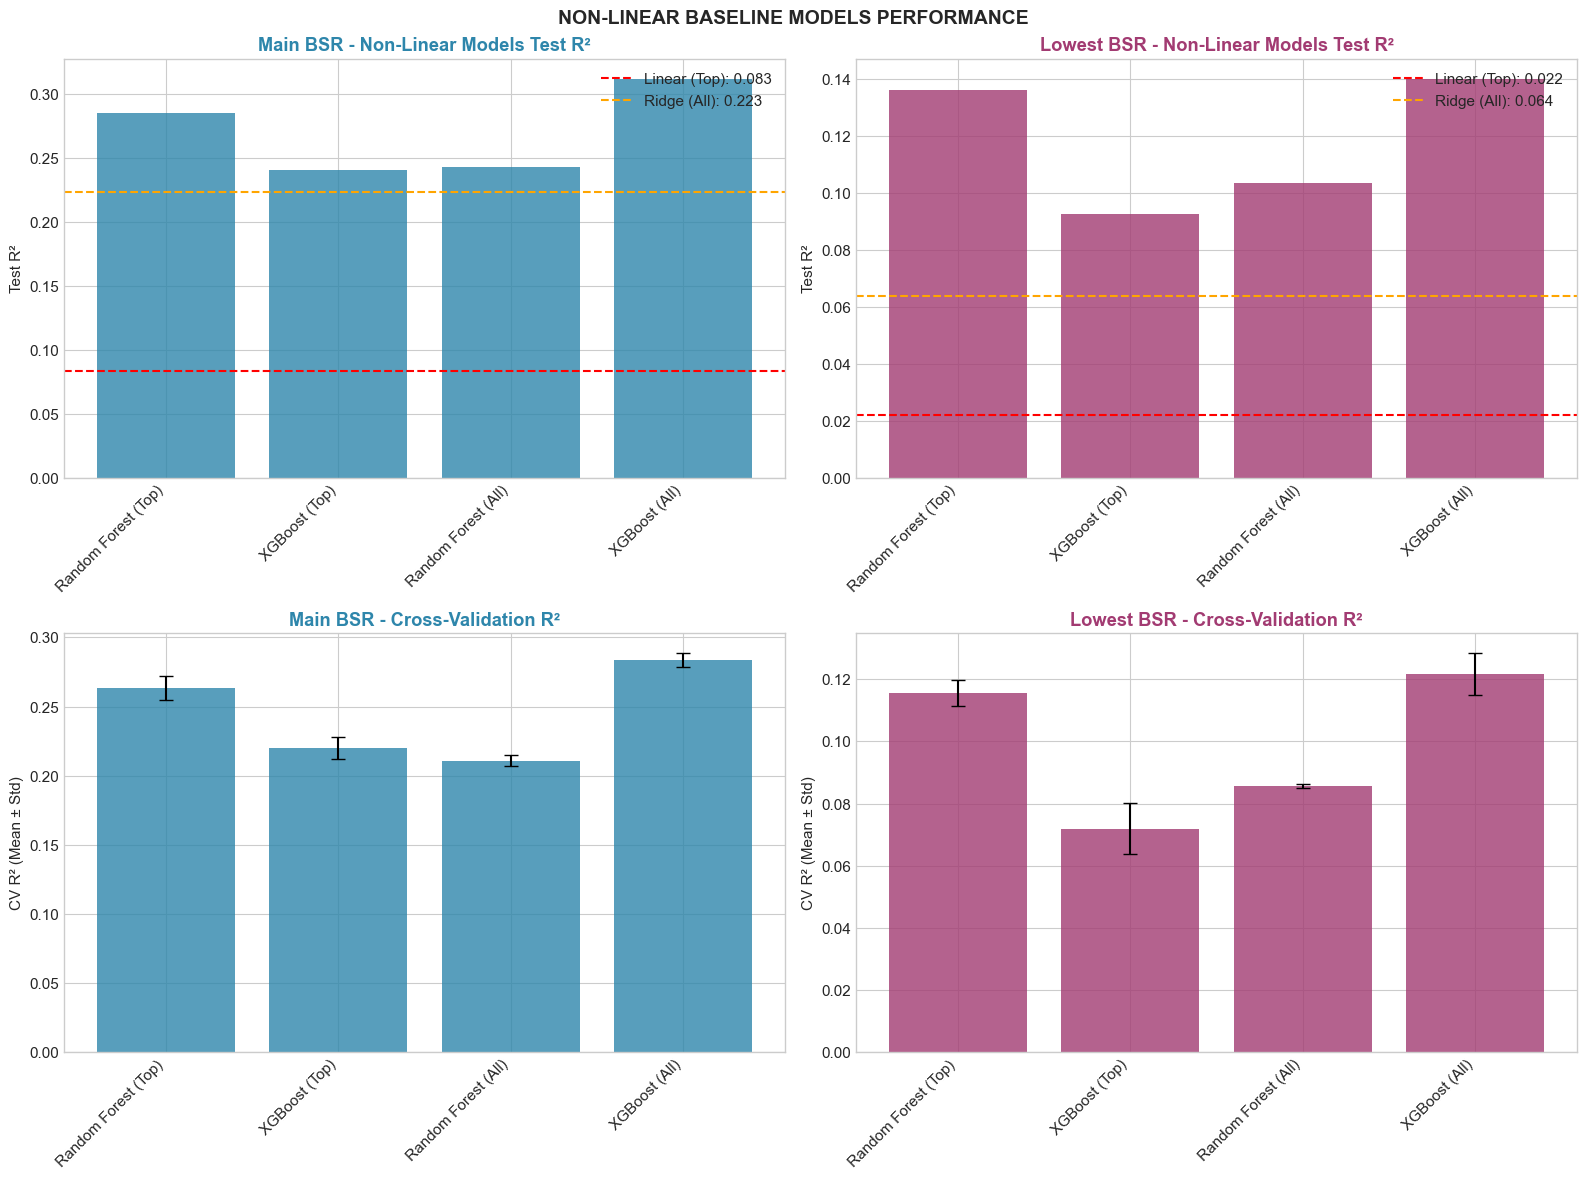

In [141]:
# =============================================================================
# 18. VISUALIZE NON-LINEAR MODEL RESULTS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Main BSR - Test R² by Model
ax1 = axes[0, 0]
main_bsr_models = nonlinear_comparison[nonlinear_comparison['Target'] == 'Main BSR']
x = np.arange(len(main_bsr_models))
bars = ax1.bar(x, main_bsr_models['Test_R2'], color=MAIN_BSR_COLOR, alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(main_bsr_models['Model'], rotation=45, ha='right')
ax1.set_ylabel('Test R²')
ax1.set_title('Main BSR - Non-Linear Models Test R²', fontweight='bold', color=MAIN_BSR_COLOR)
ax1.axhline(metrics_main_top['test_r2'], color='red', linestyle='--', 
            label=f'Linear (Top): {metrics_main_top["test_r2"]:.3f}')
ax1.axhline(metrics_main_all['test_r2'], color='orange', linestyle='--',
            label=f'Ridge (All): {metrics_main_all["test_r2"]:.3f}')
ax1.legend(loc='upper right')

# Plot 2: Lowest BSR - Test R² by Model
ax2 = axes[0, 1]
lowest_bsr_models = nonlinear_comparison[nonlinear_comparison['Target'] == 'Lowest BSR']
x = np.arange(len(lowest_bsr_models))
bars = ax2.bar(x, lowest_bsr_models['Test_R2'], color=LOWEST_BSR_COLOR, alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(lowest_bsr_models['Model'], rotation=45, ha='right')
ax2.set_ylabel('Test R²')
ax2.set_title('Lowest BSR - Non-Linear Models Test R²', fontweight='bold', color=LOWEST_BSR_COLOR)
ax2.axhline(metrics_lowest_top['test_r2'], color='red', linestyle='--',
            label=f'Linear (Top): {metrics_lowest_top["test_r2"]:.3f}')
ax2.axhline(metrics_lowest_all['test_r2'], color='orange', linestyle='--',
            label=f'Ridge (All): {metrics_lowest_all["test_r2"]:.3f}')
ax2.legend(loc='upper right')

# Plot 3: CV R² with error bars - Main BSR
ax3 = axes[1, 0]
x = np.arange(len(main_bsr_models))
ax3.bar(x, main_bsr_models['CV_R2_Mean'], yerr=main_bsr_models['CV_R2_Std'],
        color=MAIN_BSR_COLOR, alpha=0.8, capsize=5)
ax3.set_xticks(x)
ax3.set_xticklabels(main_bsr_models['Model'], rotation=45, ha='right')
ax3.set_ylabel('CV R² (Mean ± Std)')
ax3.set_title('Main BSR - Cross-Validation R²', fontweight='bold', color=MAIN_BSR_COLOR)

# Plot 4: CV R² with error bars - Lowest BSR
ax4 = axes[1, 1]
x = np.arange(len(lowest_bsr_models))
ax4.bar(x, lowest_bsr_models['CV_R2_Mean'], yerr=lowest_bsr_models['CV_R2_Std'],
        color=LOWEST_BSR_COLOR, alpha=0.8, capsize=5)
ax4.set_xticks(x)
ax4.set_xticklabels(lowest_bsr_models['Model'], rotation=45, ha='right')
ax4.set_ylabel('CV R² (Mean ± Std)')
ax4.set_title('Lowest BSR - Cross-Validation R²', fontweight='bold', color=LOWEST_BSR_COLOR)

plt.suptitle('NON-LINEAR BASELINE MODELS PERFORMANCE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best model for Main BSR (All Features): XGBoost (Test R² = 0.3115)
Best model for Lowest BSR (All Features): XGBoost (Test R² = 0.1399)


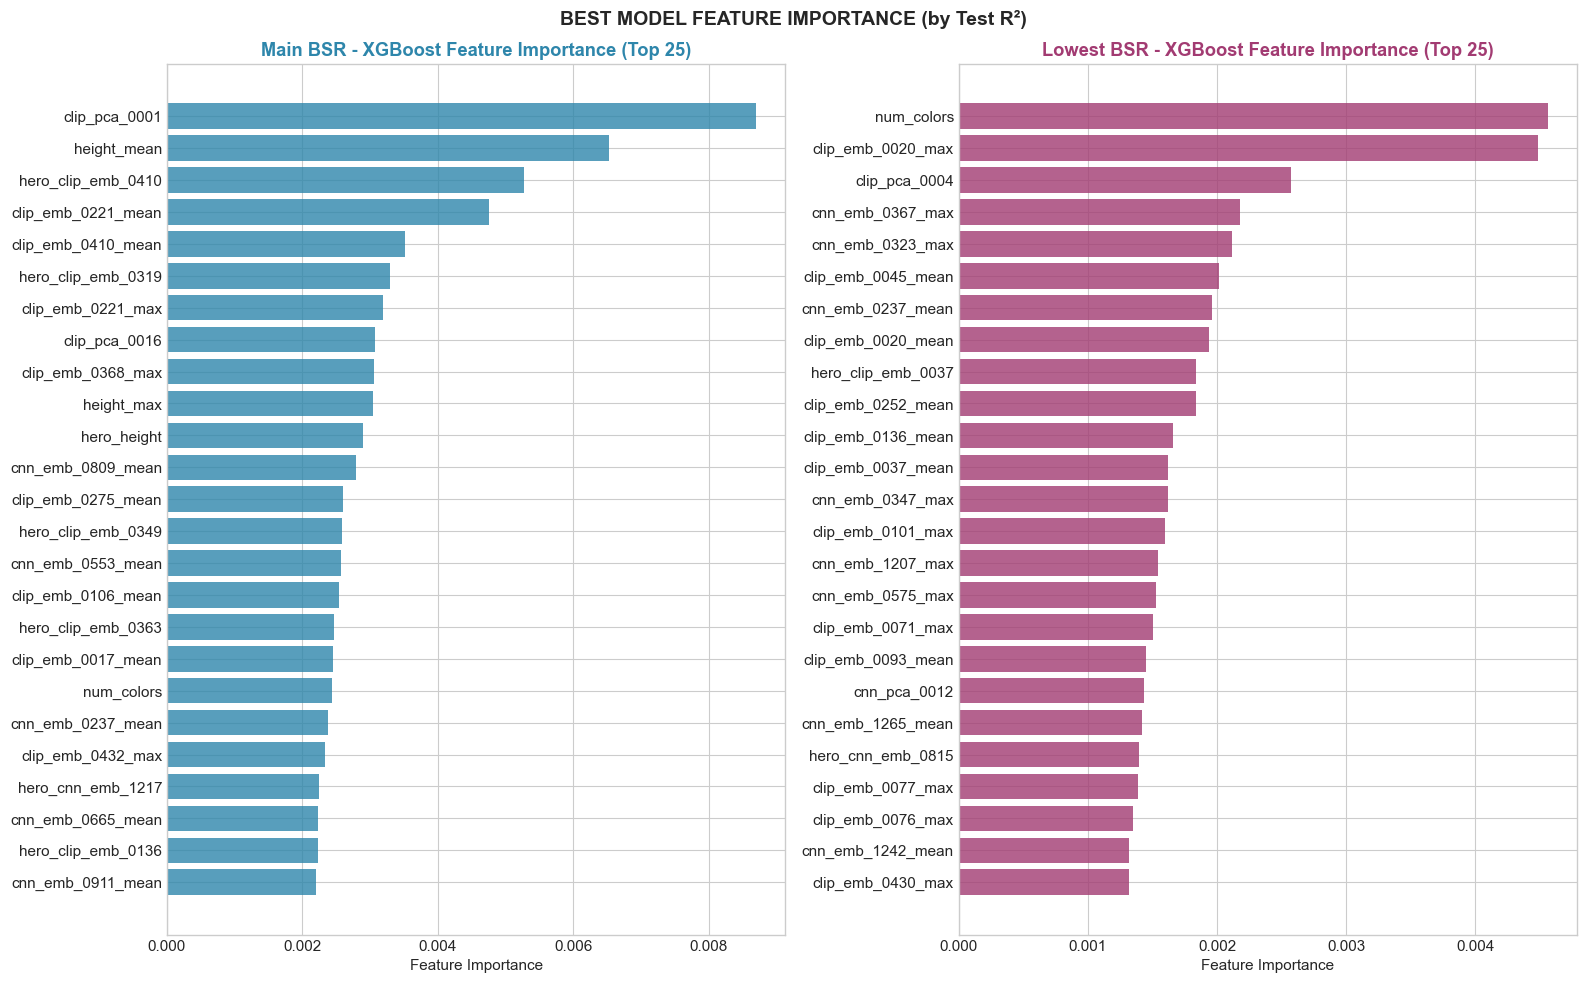

In [142]:
# =============================================================================
# 19. FEATURE IMPORTANCE (from best non-linear model by Test R²)
# =============================================================================

def get_best_model(results_dict):
    """Get the best model from results dict by test_r2"""
    best_name = max(results_dict.keys(), key=lambda k: results_dict[k]['test_r2'])
    return best_name, results_dict[best_name]

# Find best model for Main BSR (All Features)
best_name_main, best_results_main = get_best_model(nonlinear_results_main_all)
print(f"Best model for Main BSR (All Features): {best_name_main} (Test R² = {best_results_main['test_r2']:.4f})")

# Find best model for Lowest BSR (All Features)
best_name_lowest, best_results_lowest = get_best_model(nonlinear_results_lowest_all)
print(f"Best model for Lowest BSR (All Features): {best_name_lowest} (Test R² = {best_results_lowest['test_r2']:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Main BSR - Feature importance from best model
ax1 = axes[0]
best_model_main = best_results_main['model']
if hasattr(best_model_main, 'feature_importances_'):
    feat_imp_main = pd.DataFrame({
        'feature': data_main_all['feature_names'],
        'importance': best_model_main.feature_importances_
    }).sort_values('importance', ascending=False).head(25)
    
    ax1.barh(range(len(feat_imp_main)), feat_imp_main['importance'], color=MAIN_BSR_COLOR, alpha=0.8)
    ax1.set_yticks(range(len(feat_imp_main)))
    ax1.set_yticklabels([f[:30] for f in feat_imp_main['feature']])
    ax1.set_xlabel('Feature Importance')
    ax1.set_title(f'Main BSR - {best_name_main} Feature Importance (Top 25)', fontweight='bold', color=MAIN_BSR_COLOR)
    ax1.invert_yaxis()
else:
    ax1.text(0.5, 0.5, f'{best_name_main} does not have feature_importances_', 
             ha='center', va='center', transform=ax1.transAxes)

# Lowest BSR - Feature importance from best model
ax2 = axes[1]
best_model_lowest = best_results_lowest['model']
if hasattr(best_model_lowest, 'feature_importances_'):
    feat_imp_lowest = pd.DataFrame({
        'feature': data_lowest_all['feature_names'],
        'importance': best_model_lowest.feature_importances_
    }).sort_values('importance', ascending=False).head(25)
    
    ax2.barh(range(len(feat_imp_lowest)), feat_imp_lowest['importance'], color=LOWEST_BSR_COLOR, alpha=0.8)
    ax2.set_yticks(range(len(feat_imp_lowest)))
    ax2.set_yticklabels([f[:30] for f in feat_imp_lowest['feature']])
    ax2.set_xlabel('Feature Importance')
    ax2.set_title(f'Lowest BSR - {best_name_lowest} Feature Importance (Top 25)', fontweight='bold', color=LOWEST_BSR_COLOR)
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, f'{best_name_lowest} does not have feature_importances_', 
             ha='center', va='center', transform=ax2.transAxes)

plt.suptitle('BEST MODEL FEATURE IMPORTANCE (by Test R²)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [143]:
# =============================================================================
# 20. COMBINED MODEL COMPARISON (LINEAR + NON-LINEAR)
# =============================================================================

print("="*100)
print("COMPLETE MODEL COMPARISON: LINEAR + NON-LINEAR")
print("="*100)

# Add linear models to comparison
linear_rows = [
    {'Model': 'Linear Regression (Top)', 'Target': 'Main BSR', 
     'N_Features': len(data_main_top['feature_names']),
     'CV_R2_Mean': np.nan, 'CV_R2_Std': np.nan,
     'Train_R2': metrics_main_top['train_r2'], 'Test_R2': metrics_main_top['test_r2'],
     'Test_RMSE': metrics_main_top['test_rmse'], 'Test_MAE': metrics_main_top['test_mae']},
    {'Model': 'Ridge Regression (All)', 'Target': 'Main BSR',
     'N_Features': len(data_main_all['feature_names']),
     'CV_R2_Mean': np.nan, 'CV_R2_Std': np.nan,
     'Train_R2': metrics_main_all['train_r2'], 'Test_R2': metrics_main_all['test_r2'],
     'Test_RMSE': metrics_main_all['test_rmse'], 'Test_MAE': metrics_main_all['test_mae']},
    {'Model': 'Linear Regression (Top)', 'Target': 'Lowest BSR',
     'N_Features': len(data_lowest_top['feature_names']),
     'CV_R2_Mean': np.nan, 'CV_R2_Std': np.nan,
     'Train_R2': metrics_lowest_top['train_r2'], 'Test_R2': metrics_lowest_top['test_r2'],
     'Test_RMSE': metrics_lowest_top['test_rmse'], 'Test_MAE': metrics_lowest_top['test_mae']},
    {'Model': 'Ridge Regression (All)', 'Target': 'Lowest BSR',
     'N_Features': len(data_lowest_all['feature_names']),
     'CV_R2_Mean': np.nan, 'CV_R2_Std': np.nan,
     'Train_R2': metrics_lowest_all['train_r2'], 'Test_R2': metrics_lowest_all['test_r2'],
     'Test_RMSE': metrics_lowest_all['test_rmse'], 'Test_MAE': metrics_lowest_all['test_mae']},
]

all_models_comparison = pd.concat([
    pd.DataFrame(linear_rows),
    nonlinear_comparison
], ignore_index=True)

# Sort by Target and Test_R2
all_models_comparison = all_models_comparison.sort_values(['Target', 'Test_R2'], ascending=[True, False])

print("\nMain BSR Models (sorted by Test R²):")
print("-" * 100)
main_models = all_models_comparison[all_models_comparison['Target'] == 'Main BSR']
print(main_models.to_string(index=False))

print("\n\nLowest BSR Models (sorted by Test R²):")
print("-" * 100)
lowest_models = all_models_comparison[all_models_comparison['Target'] == 'Lowest BSR']
print(lowest_models.to_string(index=False))

COMPLETE MODEL COMPARISON: LINEAR + NON-LINEAR

Main BSR Models (sorted by Test R²):
----------------------------------------------------------------------------------------------------
                  Model   Target  N_Features  CV_R2_Mean  CV_R2_Std  Train_R2  Test_R2  Test_RMSE  Test_MAE
          XGBoost (All) Main BSR        7581    0.283730   0.004834  0.536373 0.311506   2.010703  1.554781
    Random Forest (Top) Main BSR          20    0.263100   0.008678  0.821137 0.284457   2.049820  1.580032
    Random Forest (All) Main BSR        7581    0.210952   0.004231  0.713738 0.242451   2.109129  1.636118
          XGBoost (Top) Main BSR          20    0.220189   0.007908  0.436468 0.240539   2.111789  1.634494
 Ridge Regression (All) Main BSR        7581         NaN        NaN  0.351070 0.222800   2.136310  1.663062
Linear Regression (Top) Main BSR          20         NaN        NaN  0.086850 0.083443   2.319944  1.807414


Lowest BSR Models (sorted by Test R²):
-----------------

In [144]:
# Save complete comparison
all_models_comparison.to_csv('all_baseline_models_comparison.csv', index=False)
print("Complete model comparison saved to: all_baseline_models_comparison.csv")

Complete model comparison saved to: all_baseline_models_comparison.csv


---
## Conclusions

In [145]:
# =============================================================================
# 21. FINAL SUMMARY & CONCLUSIONS
# =============================================================================

print("="*90)
print("BASELINE MODELING SUMMARY (LINEAR + NON-LINEAR)")
print("="*90)

print("""
KEY FINDINGS:
-------------

1. LINEAR MODELS:
   - Linear/Ridge regression provides interpretable baselines
   - Ridge regularization helps with high-dimensional feature sets
   - Coefficients indicate direction of relationship with BSR rank
   
2. NON-LINEAR MODELS:
   - Tree-based models (RF, XGBoost, LightGBM) capture non-linear patterns
   - Generally show improvement over linear models (especially with all features)
   - Watch for overfitting: compare Train R² vs Test R²
   
3. TOP FEATURES vs ALL FEATURES:
   - All features models typically outperform top-only models
   - But risk of overfitting increases with more features
   - Non-linear models handle high dimensionality better
   
4. MAIN BSR vs LOWEST BSR:
   - Main BSR generally more predictable than Lowest BSR
   - Different features may matter for each target
   
5. IMAGE FEATURES ALONE:
   - Limited predictive power for BSR (R² typically < 0.3)
   - Image quality is one factor among many affecting sales

NEXT STEPS:
-----------
- Hyperparameter tuning for best models
- Feature engineering and interaction terms
- Combine image features with other product attributes (price, category, etc.)
- Consider classification approach (BSR rank bins/tiers)
- Ensemble methods combining multiple models
""")

# Final comparison table
print("\nFINAL MODEL COMPARISON (ALL MODELS):")
print("-" * 100)
print(all_models_comparison.to_string(index=False))

BASELINE MODELING SUMMARY (LINEAR + NON-LINEAR)

KEY FINDINGS:
-------------

1. LINEAR MODELS:
   - Linear/Ridge regression provides interpretable baselines
   - Ridge regularization helps with high-dimensional feature sets
   - Coefficients indicate direction of relationship with BSR rank
   
2. NON-LINEAR MODELS:
   - Tree-based models (RF, XGBoost, LightGBM) capture non-linear patterns
   - Generally show improvement over linear models (especially with all features)
   - Watch for overfitting: compare Train R² vs Test R²
   
3. TOP FEATURES vs ALL FEATURES:
   - All features models typically outperform top-only models
   - But risk of overfitting increases with more features
   - Non-linear models handle high dimensionality better
   
4. MAIN BSR vs LOWEST BSR:
   - Main BSR generally more predictable than Lowest BSR
   - Different features may matter for each target
   
5. IMAGE FEATURES ALONE:
   - Limited predictive power for BSR (R² typically < 0.3)
   - Image quality is one fa

In [146]:
# Save model comparison results
comparison.to_csv('baseline_model_comparison.csv', index=False)
print("Model comparison saved to: baseline_model_comparison.csv")

Model comparison saved to: baseline_model_comparison.csv
